In [52]:
# # !pip install arch
# # !pip install pytorch-lightning
# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

!pip install pfhedge
import pfhedge

import pytorch_lightning as pl
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np
from arch.univariate import SkewStudent
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf

from sklearn.preprocessing import StandardScaler
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import Dataset, DataLoader
from scipy.stats import norm
from arch.univariate import SkewStudent
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
# Check if CUDA is available
print(torch.cuda.is_available())  # Should return True
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import Dataset, DataLoader
from scipy.stats import norm
from arch.univariate import SkewStudent
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 kB 3.2 MB/s eta 0:00:00
True


In [ ]:
class TimeseriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, seq_len: int = 1):
        """Initialize TimeseriesDataset
        Args:
            X: Input features array
            y: Target array
            seq_len: Length of sequence for each sample
        """
        # Ensure tensors are on CPU and in float32
        if isinstance(X, torch.Tensor):
            self.X = X.cpu().float()
        else:
            self.X = torch.tensor(X, dtype=torch.float32)

        if isinstance(y, torch.Tensor):
            self.y = y.cpu().float()
        else:
            self.y = torch.tensor(y, dtype=torch.float32)

        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, index):
        # Return tensors from CPU memory
        return (
            self.X[index:index + self.seq_len].clone(),  # clone to avoid memory issues
            self.y[index + self.seq_len - 1].clone()
        )

class ValueAtRiskDataModule(pl.LightningDataModule):
    def __init__(self, df, training_length=1000, seq_len=1, batch_size=512, num_workers=4):
        super().__init__()
        self.df = df
        self.test_case = 0
        self.seq_len = seq_len
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.preprocessing = None
        self.training_length = training_length
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def setup_train(self):
        # Get the data slice for training
        data = self.df.iloc[self.test_case:self.training_length + self.test_case]

        # Split the data into features and target
        X = data[['log_returns']].values[:self.training_length]
        y = data[['log_returns']].shift(-1).values[:self.training_length]

        # Preprocess the data
        self.preprocessing = StandardScaler()
        self.preprocessing.fit(X)

        # Transform data and keep on CPU initially
        self.X_train = torch.tensor(self.preprocessing.transform(X), dtype=torch.float32)
        self.y_train = torch.tensor(self.preprocessing.transform(y), dtype=torch.float32)

        # Prepare test data and move to device since it's used for inference
        self.X_test = torch.tensor(
            self.preprocessing.transform(
                data[['log_returns']].values[-self.seq_len - 1:-1]
            ),
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(0)

    def train_dataloader(self):
        train_dataset = TimeseriesDataset(
            self.X_train,
            self.y_train,
            seq_len=self.seq_len
        )

        return DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=4,  # Reduced from 8 to 4 for stability
            pin_memory=True,  # Keep this for faster GPU transfer
            persistent_workers=True  # Add this for better worker management
        )

    def move_timestep(self):
        self.test_case += 1

    def gather_prediction(self, predictions):
        """
        Store predictions and print status update

        Args:
            predictions: Dictionary containing predictions (VaR, Volatility, etc.)
                       or single VaR value for non-skewed models
        """
        current_position = self.test_case + self.training_length
        current_date = self.df.index[current_position]
        current_return = self.df.iloc[current_position]['log_returns']

        # Handle both dictionary and single value predictions
        if isinstance(predictions, dict):
            # Initialize columns if they don't exist
            for key in predictions.keys():
                if key not in self.df.columns:
                    self.df[key] = np.nan

            # Store all predictions
            for key, value in predictions.items():
                self.df.iloc[current_position, self.df.columns.get_loc(key)] = value

            # Print predictions
            print(f"Prediction {self.test_case + 1}")
            print(f"Date: {current_date}")
            print(f"Log Return: {current_return.iloc[0]:.6f}" if isinstance(current_return, pd.Series)
                  else f"Log Return: {current_return:.6f}")
            for key, value in predictions.items():
                print(f"{key}: {float(value):.6f}")
        else:
            # Handle single VaR value for non-skewed models
            if 'VaR' not in self.df.columns:
                self.df['VaR'] = np.nan

            self.df.iloc[current_position, self.df.columns.get_loc('VaR')] = predictions

            # Print prediction
            print(f"Prediction {self.test_case + 1}")
            print(f"Date: {current_date}")
            print(f"Log Return: {current_return.iloc[0]:.6f}" if isinstance(current_return, pd.Series)
                  else f"Log Return: {current_return:.6f}")
            print(f"VaR: {float(predictions):.6f}")

        print("-" * 50)

In [ ]:
def caviar_loss(true, pred, pval=0.025):
    # return torch.mean(-1*((true < var).float() - pval) * (true - var))
    return torch.mean(torch.max(pval*(true - pred), (pval-1)*(true - pred)))


def huber_loss(true, var, pval=torch.tensor(0.025), eps=torch.tensor(0.025)):
    x = true - var
    return torch.mean(torch.cat([
        x[x <= (pval - 1) * eps] * (pval - 1) - 1 / 2 * (pval - 1) ** 2 * eps,
        x[(x > (pval - 1) * eps) & (x <= pval * eps)] ** 2 / (2 * eps),
        x[x > pval * eps] * pval - 1 / 2 * pval ** 2 * eps
    ]))


def garch_normal_loss(true, vol):
    return 1 / 2 * torch.mean(torch.log(vol) + true ** 2 / vol)  # + tf.math.log(2 * tf.constant(np.pi))


def student_loss(true, pred):
    vol = pred[0]
    df = pred[1] + 2

    llh = + 1/2 * (
        torch.log(vol) + (1+df)*torch.log(1 + torch.square(true)/(vol * (df - 2)))
    )

    return llh


def hansen_garch_skewed_student_loss(true, pred):
    vol = pred[:, 0]
    df = pred[:, 2]
    skewness = pred[:, 1]
    true = true[:, 0]

    # Compute constants
    c = torch.lgamma((df + 1) / 2) - torch.lgamma(df / 2) - torch.log(torch.pi * (df - 2)) / 2
    a = 4 * skewness * torch.exp(c) * (df - 2) / (df - 1)
    b = torch.sqrt(1 + 3 * torch.square(skewness) - torch.square(a))

    # Normalize residuals
    z = true / torch.sqrt(vol)

    # Log likelihood components
    lls = torch.log(b) + c - torch.log(vol) / 2
    llf_resid = torch.square((b * z + a) / (1 + torch.sign(z + a / b) * skewness))
    lls -= (df + 1) / 2 * torch.log(1 + llf_resid / (df - 2))

    # Negative log likelihood
    lls *= -1

    return torch.mean(lls)

In [ ]:
class VaRNet(pl.LightningModule):
    def __init__(self,
                 n_features,
                 hidden_size,
                 seq_len,
                 batch_size,
                 num_layers,
                 dropout,
                 learning_rate,
                 criterion,
                 dist):
        super().__init__()
        self.n_features = n_features
        self.hidden_size = hidden_size
        self.seq_len = seq_len
        self.batch_size = batch_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.criterion = criterion
        self.learning_rate = learning_rate
        self.dist = dist

        # First GRU layer: input -> 32
        self.gru1 = nn.GRU(
            input_size=n_features,
            hidden_size=128,
            num_layers=1,
            dropout=dropout,
            batch_first=True
        )

        # # Second GRU layer: 32 -> 64
        # self.gru2 = nn.GRU(
        #     input_size=32,
        #     hidden_size=64,
        #     num_layers=1,
        #     dropout=dropout,
        #     batch_first=True
        # )
        # # Third GRU layer: 64 -> 128
        # self.gru3 = nn.GRU(
        #     input_size=64,
        #     hidden_size=128,
        #     num_layers=1,
        #     dropout=dropout,
        #     batch_first=True
        # )

        self.linear = nn.Linear(128,256)  # Input from GRU3 output 128->256
        self.linear2 = nn.Linear(256,128)                          #256->256

    def forward(self, x):
        # Process through all three GRU layers
        gru1_out, _ = self.gru1(x)
        y_pred = self.linear(gru1_out[:, -1])
        y_pred = self.linear2(y_pred)
        return y_pred

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y, y_hat)
        self.log('train_loss', loss, on_epoch=True)
        return loss

    def predict_var(self, x):
        self.eval()
        with torch.no_grad():
            x = x.to(self.device)
            output = self(x)
            output = output.cpu().numpy()[0]

            vol = output[0]
            skew = np.clip(output[1], -0.99, 0.99)
            df = np.clip(output[2], 3, 300.0)

            dist = self.dist()
            ppf_value = dist.ppf(0.025, [df, skew])
            var = np.sqrt(vol) * ppf_value

            return {
                'VaR': var,
                'Volatility': vol,
                'Skewness': skew,
                'DegreesOfFreedom': df
            }

class GARCHVaRNet(VaRNet):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.softplus = nn.Softplus()

    def forward(self, x):
        gru1_out, _ = self.gru1(x)
        gru2_out, _ = self.gru2(gru1_out)
        gru3_out, _ = self.gru3(gru2_out)
        y_pred = self.linear(gru3_out[:, -1])
        y_pred = self.linear2(y_pred)
        return self.softplus(y_pred)

class SkewedGARCHVaRNet(GARCHVaRNet):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.linear3_1 = nn.Linear(128, 1)

        self.linear3_2 = nn.Linear(128, 1)

        self.linear3_3 = nn.Linear(128, 1)

        self.tanh = nn.Tanh()
        self.elu = nn.ELU()

    def forward(self, x):
        x = x.to(self.device)
        gru1_out, _ = self.gru1(x)
        y_pred = self.linear(gru1_out[:, -1])
        y_pred = self.linear2(y_pred)

        vol = self.softplus(self.linear3_1(y_pred))
        skew = self.tanh(self.linear3_2(y_pred))
        df = 4 + self.elu(self.linear3_3(y_pred))  # Changed to ELU

        return torch.cat([vol, skew, df], dim=1)

In [ ]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
import numpy as np

class VaRNet(pl.LightningModule):
    def __init__(self,
                 n_features,
                 hidden_size,
                 seq_len,
                 batch_size,
                 num_layers,
                 dropout,
                 learning_rate,
                 criterion,
                 dist):
        super().__init__()
        self.n_features = n_features
        self.hidden_size = hidden_size
        self.seq_len = seq_len
        self.batch_size = batch_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.criterion = criterion
        self.learning_rate = learning_rate
        self.dist = dist

        # First GRU layer
        self.gru1 = nn.GRU(
            input_size=n_features,
            hidden_size=128,
            num_layers=1,
            dropout=dropout,
            batch_first=True
        )

        # Fully connected layers
        self.linear = nn.Linear(128, 256)  # GRU output to 256
        self.linear2 = nn.Linear(256 + n_features, 128)  # Skip connection added

    def forward(self, x):
        # Pass input through GRU
        gru1_out, _ = self.gru1(x)
        gru_last_hidden = gru1_out[:, -1]  # Take the last hidden state

        # Process through linear layers
        intermediate_output = self.linear(gru_last_hidden)

        # Concatenate the input features (skip connection)
        skip_connection = torch.cat([intermediate_output, x[:, -1, :]], dim=1)  # Concatenate with the last time step input
        y_pred = self.linear2(skip_connection)
        return y_pred

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y, y_hat)
        self.log('train_loss', loss, on_epoch=True)
        return loss

    def predict_var(self, x):
        self.eval()
        with torch.no_grad():
            x = x.to(self.device)
            output = self(x)
            output = output.cpu().numpy()[0]

            vol = output[0]
            skew = np.clip(output[1], -0.99, 0.99)
            df = np.clip(output[2], 3, 300.0)

            dist = self.dist()
            ppf_value = dist.ppf(0.025, [df, skew])
            var = np.sqrt(vol) * ppf_value

            return {
                'VaR': var,
                'Volatility': vol,
                'Skewness': skew,
                'DegreesOfFreedom': df
            }

class GARCHVaRNet(VaRNet):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.softplus = nn.Softplus()

    def forward(self, x):
        gru1_out, _ = self.gru1(x)
        gru_last_hidden = gru1_out[:, -1]

        # Process through linear layers
        intermediate_output = self.linear(gru_last_hidden)

        # Concatenate input features (skip connection)
        skip_connection = torch.cat([intermediate_output, x[:, -1, :]], dim=1)
        y_pred = self.linear2(skip_connection)
        return self.softplus(y_pred)

class SkewedGARCHVaRNet(GARCHVaRNet):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.linear3_1 = nn.Linear(128, 1)
        self.linear3_2 = nn.Linear(128, 1)
        self.linear3_3 = nn.Linear(128, 1)

        self.tanh = nn.Tanh()
        self.elu = nn.ELU()

    def forward(self, x):
        gru1_out, _ = self.gru1(x)
        gru_last_hidden = gru1_out[:, -1]

        # Process through linear layers
        intermediate_output = self.linear(gru_last_hidden)

        # Concatenate input features (skip connection)
        skip_connection = torch.cat([intermediate_output, x[:, -1, :]], dim=1)
        y_pred = self.linear2(skip_connection)

        vol = self.softplus(self.linear3_1(y_pred))
        skew = self.tanh(self.linear3_2(y_pred))
        df = 4 + self.elu(self.linear3_3(y_pred))  # Changed to ELU

        return torch.cat([vol, skew, df], dim=1)


In [ ]:
def experiment_nikkei(model_name='garch_skew'):
    # Set up device and print info
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    final_model = None
    final_dm = None
    final_device = None

    # Model setup with proper configuration
    if model_name == 'garch_skew':
        model_class = SkewedGARCHVaRNet
        dist = SkewStudent
        loss = hansen_garch_skewed_student_loss
    elif model_name == 'garch_norm':
        model_class = GARCHVaRNet
        dist = norm
        loss = garch_normal_loss
    elif model_name == 'caviar':
        model_class = VaRNet
        dist = None
        loss = caviar_loss
    elif model_name == 'caviar_huber':
        model_class = VaRNet
        dist = None
        loss = huber_loss
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    # Download and prepare Nikkei data
    nikkei = yf.download('^N225', start='2000-01-01')
    data = nikkei[['Close']].copy()
    data['log_returns'] = np.log(data['Close'] / data['Close'].shift(1))
    data = data.dropna()

    # Initialize columns based on model type
    data['VaR'] = np.nan
    if model_name == 'garch_skew':
        data['Volatility'] = np.nan
        data['StandardDeviation'] = np.nan  # New column
        data['Skewness'] = np.nan
        data['DegreesOfFreedom'] = np.nan


    # Training parameters setup
    memory_sizes = [16]
    total_samples = len(data)
    sample_points = [int(total_samples * 0.8165)]
    sample_dates = [data.index[point].strftime('%Y-%m-%d') for point in sample_points]


    class DeviceAwareDataModule(ValueAtRiskDataModule):
        def __init__(self, *args, device=None, **kwargs):
            super().__init__(*args, **kwargs)
            self.device = device if device is not None else torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        def setup_train(self):
            super().setup_train()
            if self.X_train is not None:
                self.X_train = self.X_train.to(self.device)
            if self.y_train is not None:
                self.y_train = self.y_train.to(self.device)
            if self.X_test is not None:
                self.X_test = self.X_test.to(self.device)

    class ModelWithScheduler(model_class):
        def configure_optimizers(self):
            optimizer = torch.optim.AdamW(
                self.parameters(),
                lr=self.learning_rate,
                weight_decay=0.01  # Add explicit weight decay
            )
            scheduler = {
                'scheduler': torch.optim.lr_scheduler.StepLR(
                    optimizer,
                    step_size=25,
                    gamma=0.5
                ),
                'interval': 'epoch'
            }
            return [optimizer], [scheduler]

    # Training loop
    for mem_size in memory_sizes:
        # Training parameters
        p = dict(
            training_length=1000,
            seq_len=mem_size,
            batch_size=512,
            criterion=loss,
            max_epochs=300,
            n_features=1,
            hidden_size=128,
            num_layers=1,
            dropout=0,
            learning_rate=8e-4,
            num_train=100
        )

        for sample_start in sample_dates:
            # Prepare data for current sample
            current_data = data.loc[(data.index > sample_start)].copy()

            # Initialize data module with appropriate columns
            if model_name == 'garch_skew':
                columns = ['log_returns', 'VaR', 'Volatility', 'StandardDeviation', 'Skewness', 'DegreesOfFreedom']
            else:
                columns = ['log_returns', 'VaR']

            dm = DeviceAwareDataModule(
                df=current_data[columns],
                training_length=p['training_length'],
                seq_len=p['seq_len'],
                batch_size=p['batch_size'],
                num_workers=4,
                device=device
            )

            for test_case in range(p['num_train']):
                print(f"Processing test case {test_case + 1}/{p['num_train']}")
                model = ModelWithScheduler(
                    n_features=p['n_features'],
                    hidden_size=p['hidden_size'],
                    seq_len=p['seq_len'],
                    batch_size=p['batch_size'],
                    criterion=p['criterion'],
                    num_layers=p['num_layers'],
                    dropout=p['dropout'],
                    learning_rate=p['learning_rate'],
                    dist=dist
                ).to(device)
                # Configure trainer
                trainer = Trainer(
                    max_epochs=p['max_epochs'],
                    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
                    devices=1,
                    enable_progress_bar=True,
                    log_every_n_steps=1,
                    enable_model_summary=True,
                    enable_checkpointing=False,  # Changed to False
                )

                # Setup and train
                dm.setup_train()
                trainer.fit(model, dm)

                # Make predictions
                try:
                    with torch.no_grad():
                        predictions = model.predict_var(dm.X_test)

                        if isinstance(predictions, dict):
                            # Handle dictionary of predictions (skewed model)
                            transformed_predictions = predictions.copy()
                            # Transform VaR back to original scale
                            transformed_predictions['VaR'] = dm.preprocessing.inverse_transform(
                                np.array(predictions['VaR']).reshape(-1, 1)
                            )[0][0]
                            # Handle volatility and standard deviation transformation
                            # First get standard deviation in standardized scale
                            scaled_std = np.sqrt(predictions['Volatility'])

                            # Transform standard deviation back to original scale
                            original_std = dm.preprocessing.inverse_transform(
                                np.array([[scaled_std]])
                            )[0][0]

                            # Store both volatility and standard deviation
                            transformed_predictions['StandardDeviation'] = original_std
                            transformed_predictions['Volatility'] = original_std ** 2

                            # Store all predictions
                            dm.gather_prediction(transformed_predictions)

                        else:
                            # Handle single VaR prediction (other models)
                            if isinstance(predictions, torch.Tensor):
                                predictions = predictions.cpu().numpy()
                            predictions = np.array(predictions).reshape(-1, 1)
                            transformed_prediction = dm.preprocessing.inverse_transform(predictions)[0][0]
                            dm.gather_prediction(transformed_prediction)


                except Exception as e:
                    print(f"Error during prediction: {str(e)}")
                    continue


                # Move to next timestep
                dm.move_timestep()

            # Save results for current sample
            output_filename = f'nikkei_{model_name}_{sample_start}_{mem_size}.csv'
            dm.df[columns].to_csv(output_filename)
            print(f"Results saved to {output_filename}")
            # Store final state
            final_model = model
            final_dm = dm
            final_device = device
    return final_model, final_dm, final_device


In [ ]:
if __name__ == "__main__":
    # Run experiment and get final model and data module
    trained_model, final_dm, device = experiment_nikkei('garch_skew')


[*********************100%***********************]  1 of 1 completed
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Using device: cuda
Processing test case 1/100


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type     | Params | Mode 
-----------------------------------------------
0 | gru1      | GRU      | 50.3 K | train
1 | linear    | Linear   | 33.0 K | train
2 | linear2   | Linear   | 33.0 K | train
3 | softplus  | Softplus | 0      | train
4 | linear3_1 | Linear   | 129    | train
5 | linear3_2 | Linear   | 129    | train
6 | linear3_3 | Linear   | 129    | train
7 | tanh      | Tanh     | 0      | train
8 | elu       | ELU      | 0      | train
-----------------------------------------------
116 K     Trainable params
0         Non-trainable params
116 K     Total params
0.467     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=300` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type     | Params | Mode 
-----------------------------------------------
0 | gru1      | GRU      | 50.3 K | train
1 | linear    | Linear   | 33.0 K | train
2 | linear2   | Linear   | 33.0 K | train
3 | softplus  | Softplus | 0      | train
4 | linear3_1 | Linear   | 129    | train
5 | linear3_2 | Linear   | 129    | train
6 | linear3_3 | Linear   | 129    | train
7 | tanh      | Tanh     | 0      | train
8 | elu       | ELU      | 0      | train
-----------------------------------------------
116 K     Traina

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=300` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type     | Params | Mode 
-----------------------------------------------
0 | gru1      | GRU      | 50.3 K | train
1 | linear    | Linear   | 33.0 K | train
2 | linear2   | Linear   | 33.0 K | train
3 | softplus  | Softplus | 0      | train
4 | linear3_1 | Linear   | 129    | train
5 | linear3_2 | Linear   | 129    | train
6 | linear3_3 | Linear   | 129    | train
7 | tanh      | Tanh     | 0      | train
8 | elu       | ELU      | 0      | train
-----------------------------------------------
116 K     Traina

Prediction 99
Date: 2024-12-05 00:00:00
Log Return: 0.003031
VaR: -0.022930
Volatility: 0.000134
Skewness: -0.110634
DegreesOfFreedom: 7.134826
StandardDeviation: 0.011592
--------------------------------------------------
Processing test case 100/100


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=300` reached.


Prediction 100
Date: 2024-12-06 00:00:00
Log Return: -0.007758
VaR: -0.024500
Volatility: 0.000147
Skewness: -0.152546
DegreesOfFreedom: 7.158841
StandardDeviation: 0.012114
--------------------------------------------------
Results saved to nikkei_garch_skew_2020-06-11_16.csv


In [35]:
def check_initial_parameters(trained_model, final_dm):
    trained_model.eval()
    device = next(trained_model.parameters()).device

    # Get initial window and its raw values
    current_window = final_dm.X_test.clone().to(device)

    print("\nInput Data Check:")
    print("-" * 50)
    print("X_test shape:", final_dm.X_test.shape)
    print("First window of returns (scaled):", final_dm.X_test[0, :, 0].cpu().numpy())

    # Get original unscaled values
    unscaled_returns = final_dm.preprocessing.inverse_transform(
        final_dm.X_test[0, :, 0].cpu().numpy().reshape(-1, 1)
    )
    print("\nFirst window of returns (unscaled):", unscaled_returns.flatten())

    # Get initial predictions
    initial_predictions = trained_model.predict_var(current_window)

    print("\nModel Output Check:")
    print("-" * 50)
    print("Raw model outputs:")
    for key, value in initial_predictions.items():
        if isinstance(value, torch.Tensor):
            value = value.cpu().numpy()
        print(f"{key}: {value}")

    print("\nUnscaled values:")
    # Unscale volatility and VaR
    vol_value = initial_predictions['Volatility']
    if isinstance(vol_value, torch.Tensor):
        vol_value = vol_value.cpu().numpy()
    unscaled_vol = final_dm.preprocessing.inverse_transform(
        np.array([[vol_value]])
    )[0][0]

    var_value = initial_predictions['VaR']
    if isinstance(var_value, torch.Tensor):
        var_value = var_value.cpu().numpy()
    unscaled_var = final_dm.preprocessing.inverse_transform(
        np.array([[var_value]])
    )[0][0]

    print(f"Volatility - Scaled: {vol_value:.6f}")
    print(f"Volatility - Unscaled: {unscaled_vol:.6f}")
    print(f"VaR - Scaled: {var_value:.6f}")
    print(f"VaR - Unscaled: {unscaled_var:.6f}")

    skew_value = initial_predictions['Skewness']
    if isinstance(skew_value, torch.Tensor):
        skew_value = skew_value.cpu().numpy()
    df_value = initial_predictions['DegreesOfFreedom']
    if isinstance(df_value, torch.Tensor):
        df_value = df_value.cpu().numpy()

    print(f"Skewness: {skew_value:.6f}")
    print(f"DegreesOfFreedom: {df_value:.6f}")

    return {
        'raw_predictions': initial_predictions,
        'unscaled_vol': unscaled_vol,
        'unscaled_var': unscaled_var,
        'input_returns': unscaled_returns
    }

In [36]:
results = check_initial_parameters(trained_model, final_dm)


Input Data Check:
--------------------------------------------------
X_test shape: torch.Size([1, 16, 1])
First window of returns (scaled): [-1.3271254  -0.40765747  0.17673557 -0.8824199   0.35174456 -0.16162193
 -0.6945156   0.48271757  0.95428944 -0.71120155 -0.6543405   0.39379877
 -0.32069284  0.5748599   1.4196538   0.01686196]

First window of returns (unscaled): [-0.01675964 -0.00481407  0.00277826 -0.0109821   0.00505194 -0.00161762
 -0.00854088  0.00675352  0.0128801  -0.00875766 -0.00801894  0.0055983
 -0.00368424  0.00795062  0.01892603  0.00070121]

Model Output Check:
--------------------------------------------------
Raw model outputs:
VaR: -1.9229030810682672
Volatility: 0.8016587495803833
Skewness: -0.15254637598991394
DegreesOfFreedom: 7.158841133117676

Unscaled values:
Volatility - Scaled: 0.801659
Volatility - Unscaled: 0.010897
VaR - Scaled: -1.922903
VaR - Unscaled: -0.024500
Skewness: -0.152546
DegreesOfFreedom: 7.158841


In [30]:
def simulate_path_dependent_returns(model, data_module, n_future_steps=20, n_simulations=5000):
    model.eval()
    device = next(model.parameters()).device
    dist = SkewStudent()

    # Initialize storage
    simulated_returns = np.zeros((n_simulations, n_future_steps))
    simulated_params = {
        'Volatility': np.zeros((n_simulations, n_future_steps)),
        'Skewness': np.zeros((n_simulations, n_future_steps)),
        'DegreesOfFreedom': np.zeros((n_simulations, n_future_steps))
    }

    # Get initial window (t-8 to t-1)
    current_window = data_module.X_test.clone().to(device)

    # For each simulation path
    for sim in range(n_simulations):
        sim_window = current_window.clone()

        for t in range(n_future_steps):
            # Get raw model outputs [vol, skew, df]
            with torch.no_grad():
                outputs = model(sim_window)  # This gives concatenated [vol, skew, df]

                # Extract individual parameters
                variance_t = outputs[0, 0].cpu().numpy()  # First parameter is variance
                skew_t = outputs[0, 1].cpu().numpy()  # Second parameter is skewness
                df_t = outputs[0, 2].cpu().numpy()    # Third parameter is degrees of freedom

                # Convert variance to standard deviation and unscale
                std_t = np.sqrt(variance_t)  # Convert variance to std dev
                std_t = data_module.preprocessing.inverse_transform(
                    np.array([[std_t]])
                )[0][0]
                # Convert back to variance (unscaled)
                vol_t = std_t** 2

            # Store parameters
            simulated_params['Volatility'][sim, t] = vol_t
            simulated_params['Skewness'][sim, t] = skew_t
            simulated_params['DegreesOfFreedom'][sim, t] = df_t

            # Generate return using parameters
            u = np.random.uniform(0, 1)
            z_t = float(dist.ppf(u, parameters=[df_t, skew_t]))
            return_t = std_t * z_t  # Use standard deviation (sqrt of variance)
            simulated_returns[sim, t] = return_t

            # Update window
            scaled_return = data_module.preprocessing.transform([[return_t]])[0][0]
            new_tensor = torch.tensor([[[scaled_return]]], dtype=torch.float32).to(device)
            sim_window = torch.cat([sim_window[:, 1:, :], new_tensor], dim=1)

    return simulated_returns, simulated_params





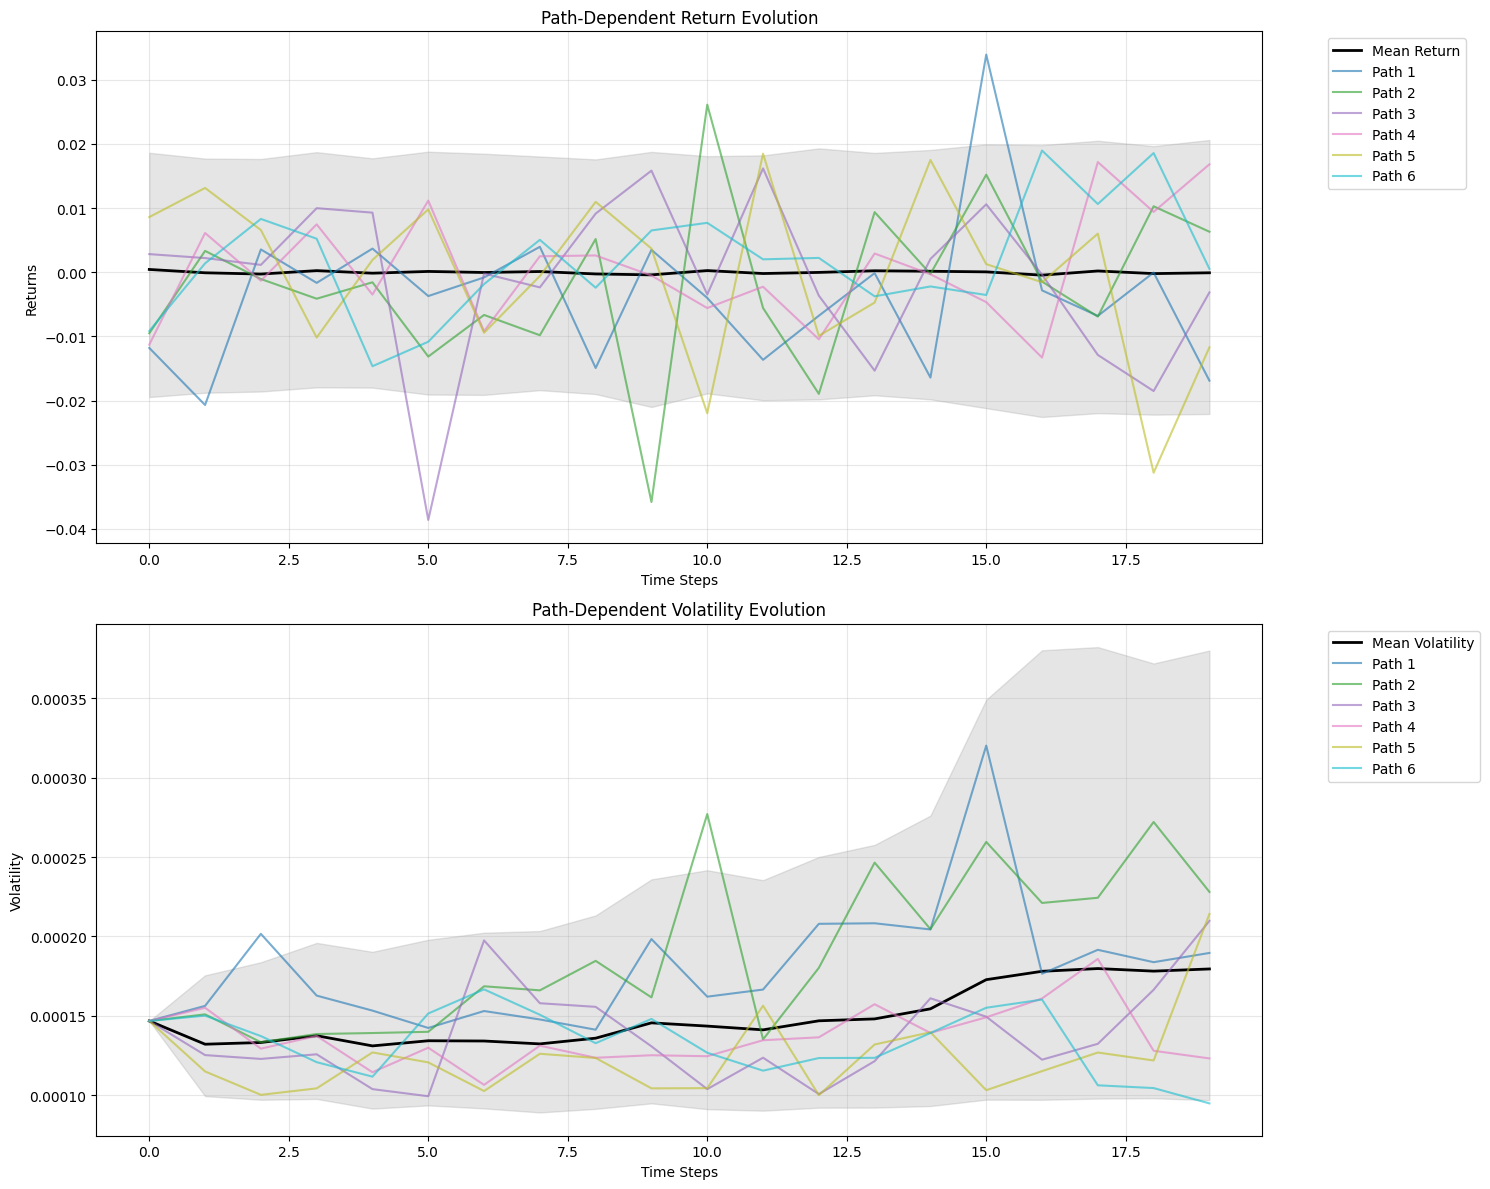

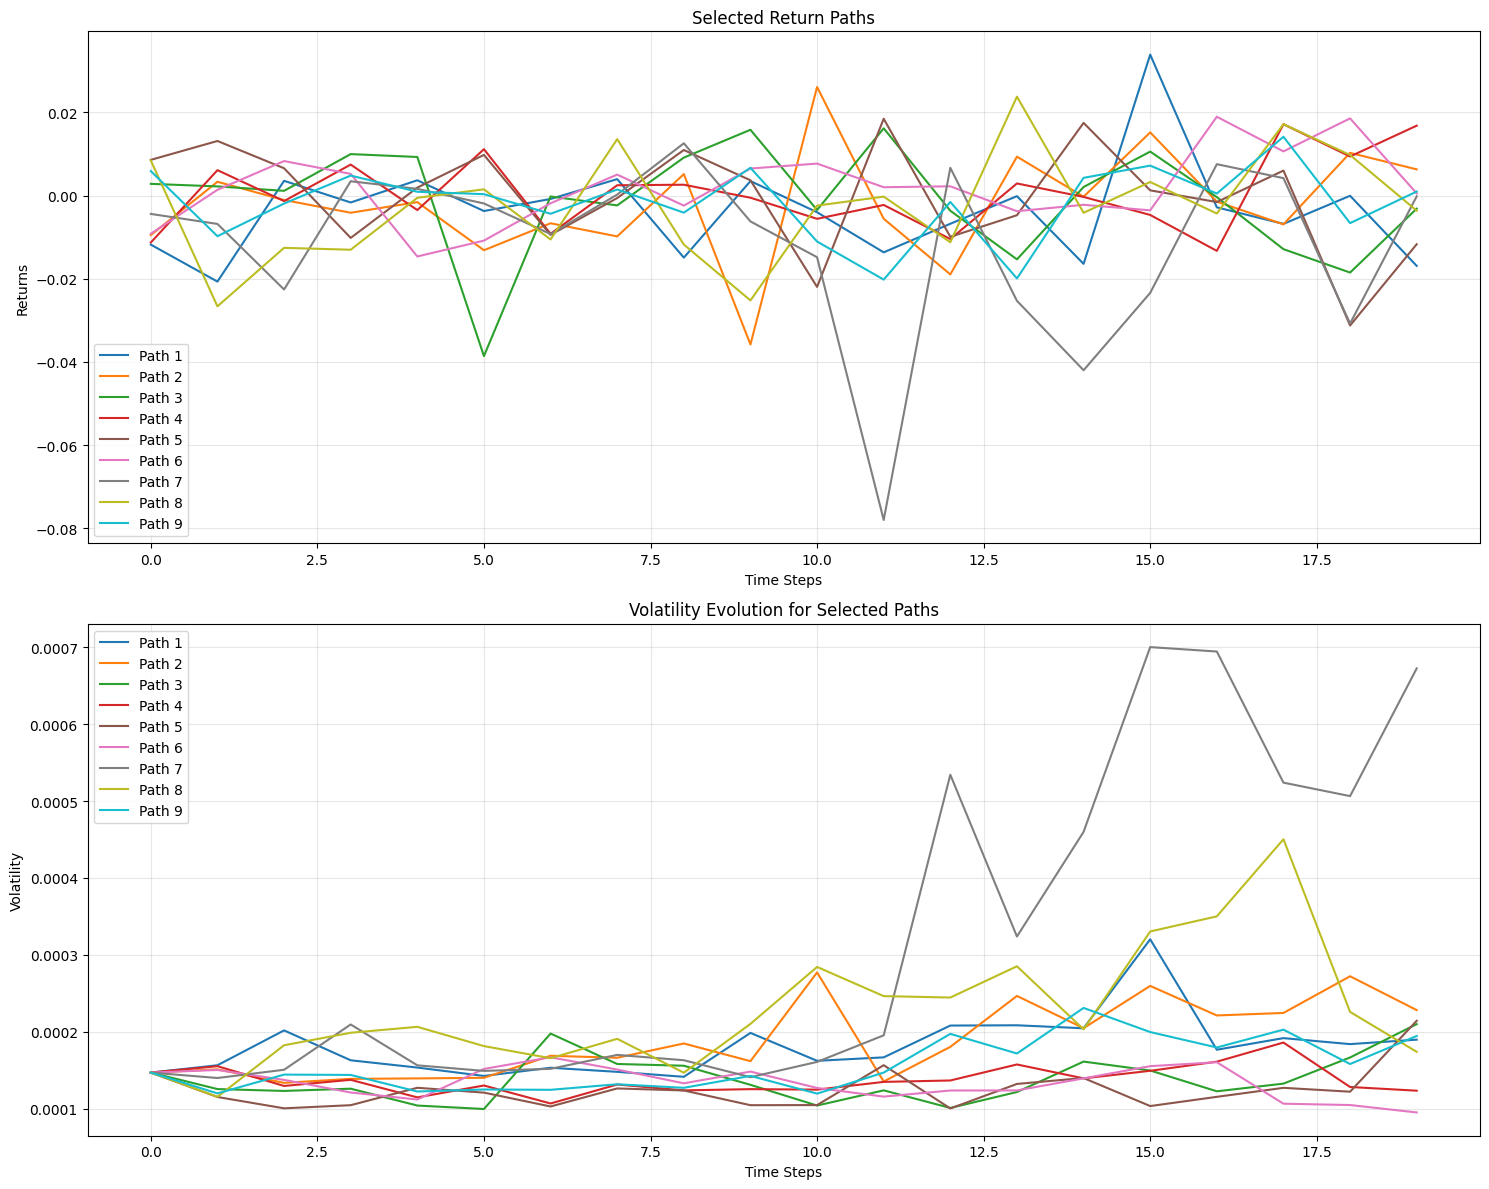

In [247]:
# simulation_returns, simulation_params = simulate_path_dependent_returns(trained_model, final_dm)
analyze_path_dependent_simulations(simulation_returns, simulation_params)

# Look at specific paths if needed
plot_specific_paths(simulation_returns, simulation_params, [0, 1, 2,3,4,5,6,7,8])  # Examine first three paths

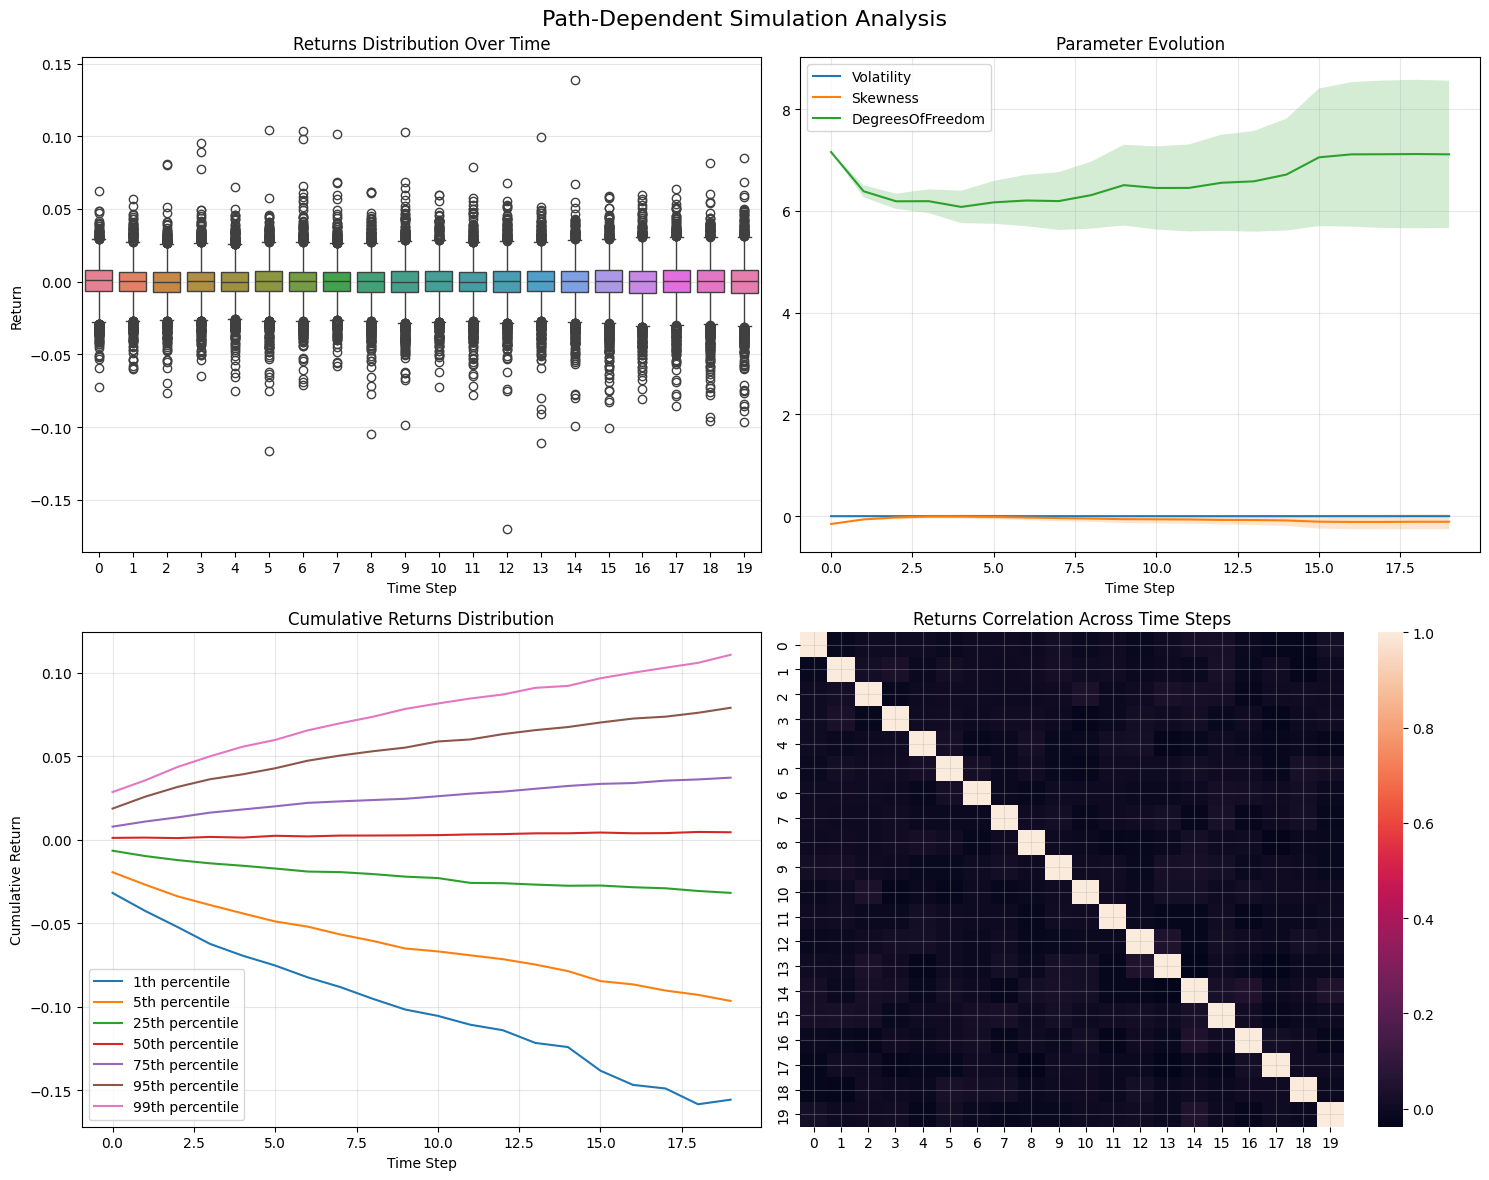

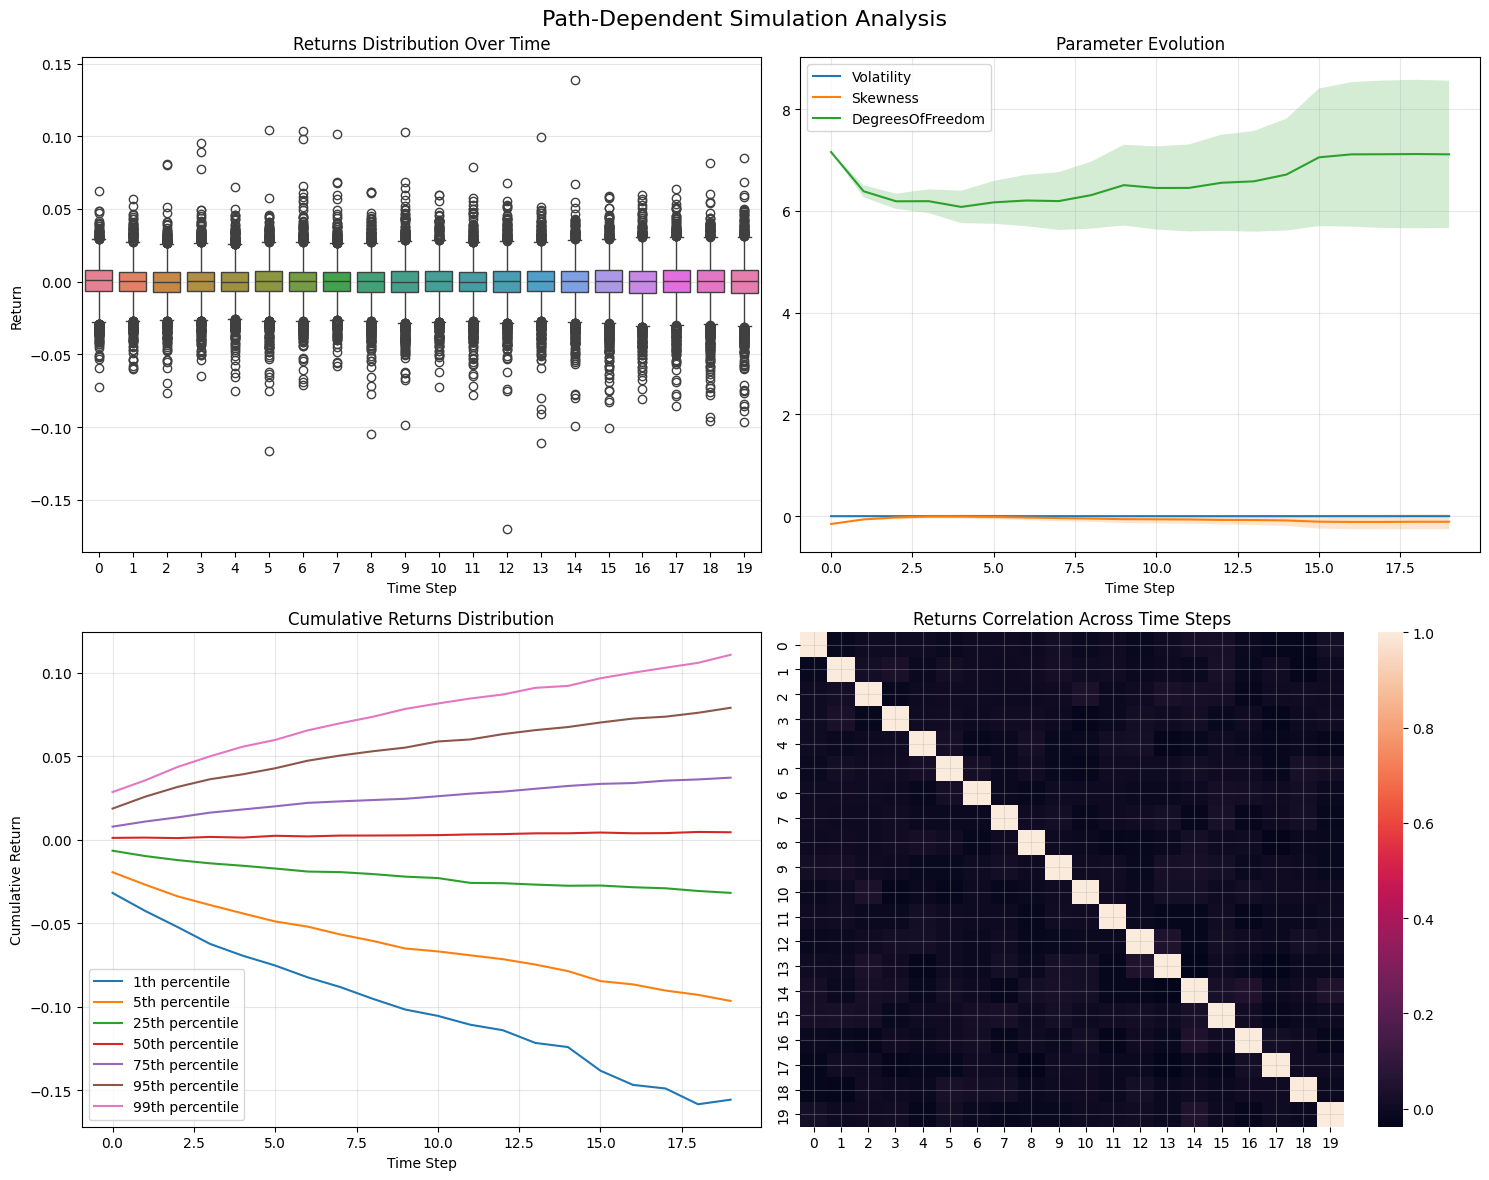

In [240]:
# simulation_returns, simulation_params = simulate_path_dependent_returns(trained_model, final_dm)
# analyze_path_dependent_simulations(simulation_returns, simulation_params)
plot_specific_paths(simulation_returns, simulation_params, [0, 1, 2,3,4,5,6,7,8])  # Examine first three paths

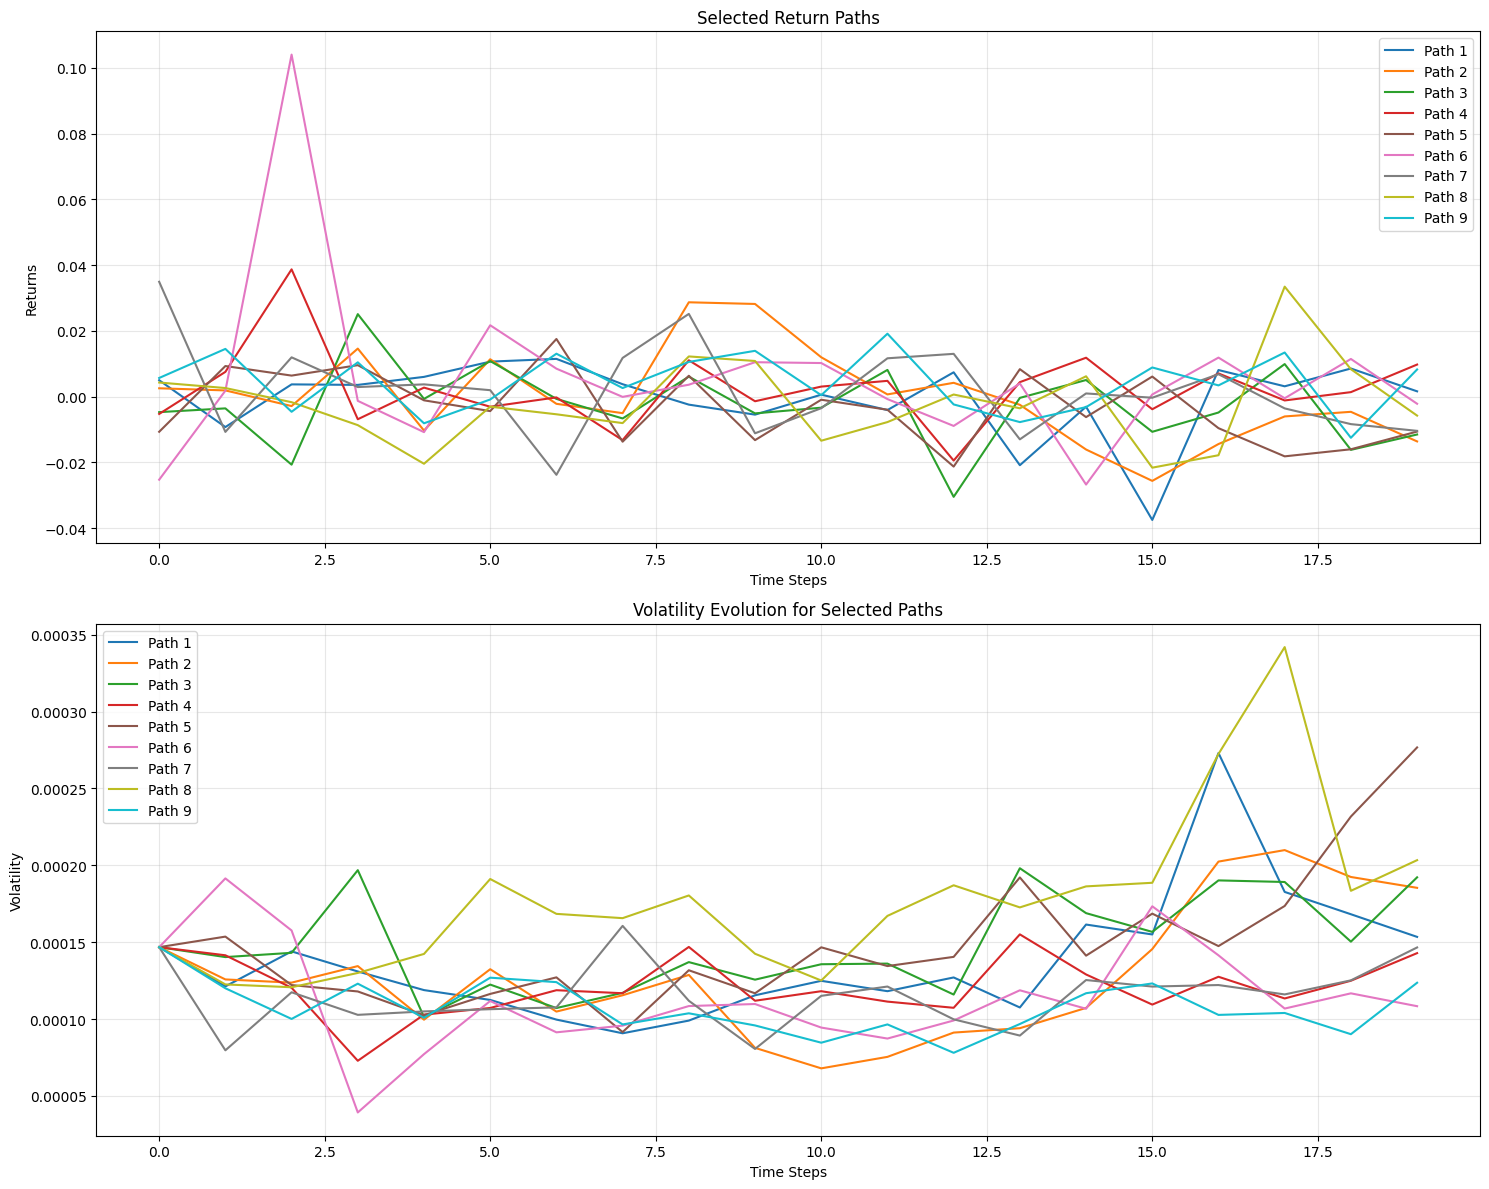

In [33]:
plot_specific_paths(simulation_returns, simulation_params, [0, 1, 2,3,4,5,6,7,8])  # Examine first three paths

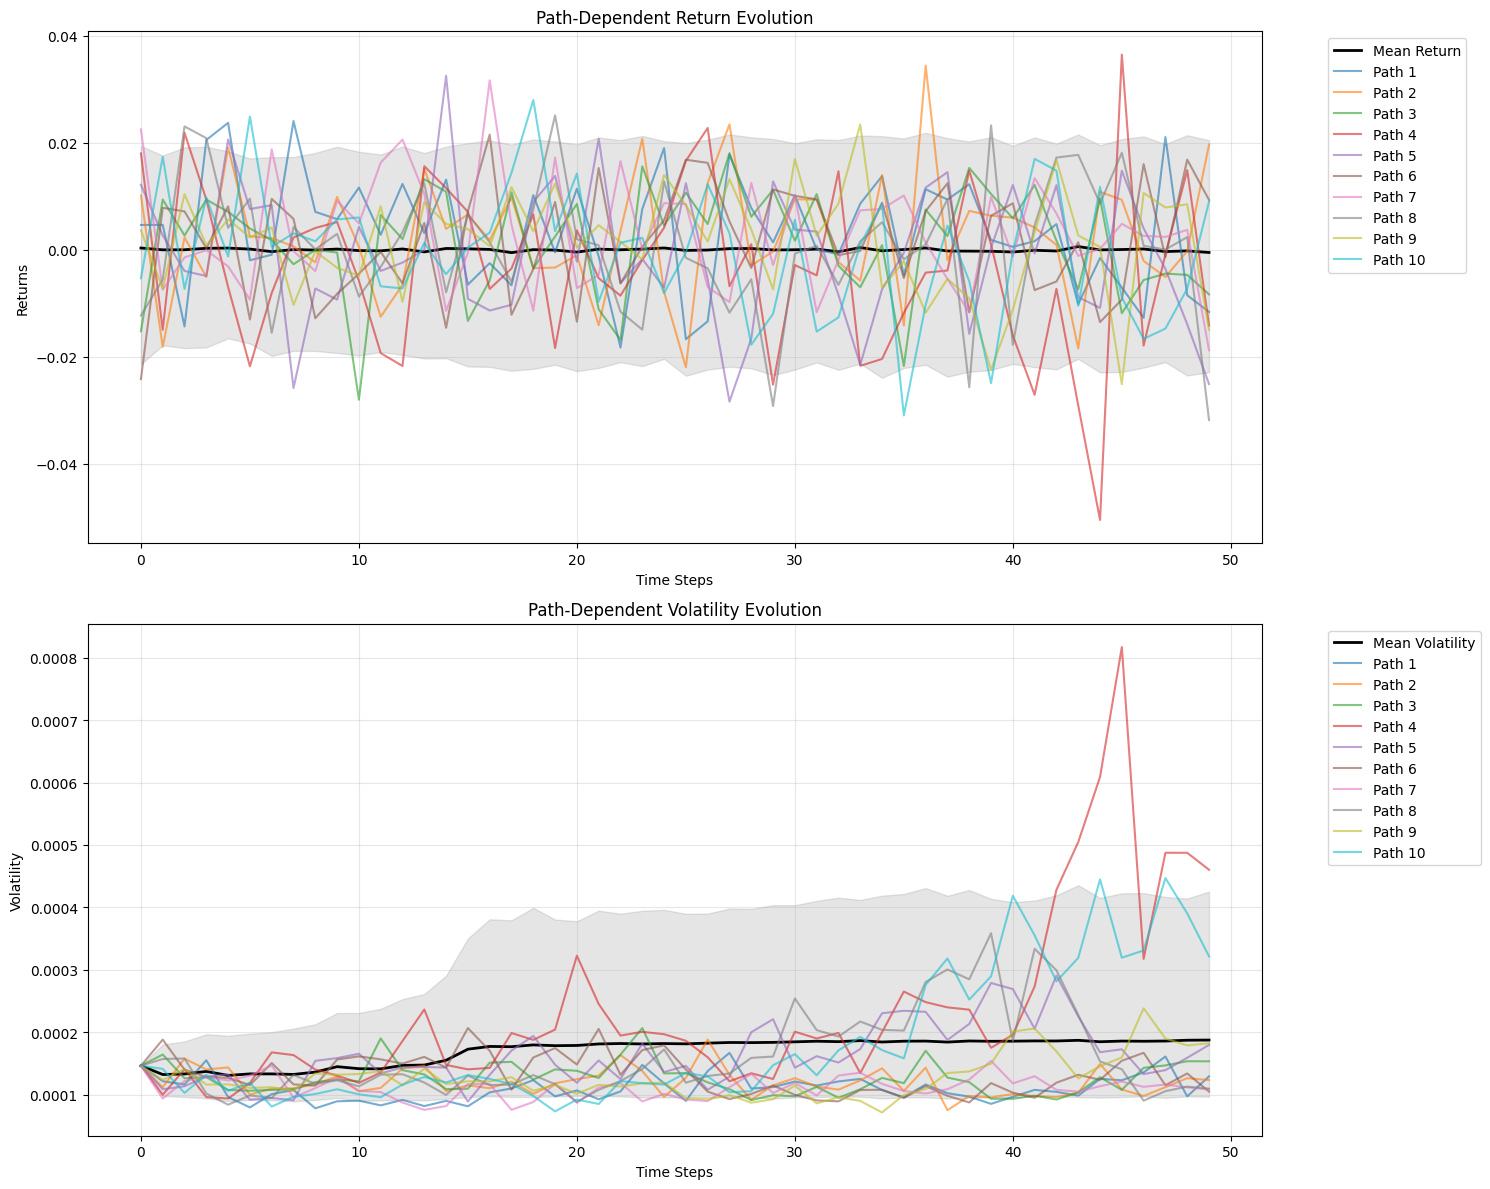

In [26]:
analyze_path_dependent_simulations(simulation_returns, simulation_params)


In [246]:
def analyze_path_dependent_simulations(returns, params, n_display_paths=6):
    """
    Show path-dependent evolution of both returns and volatility using 5th and 95th percentiles
    """
    # Set basic style parameters
    plt.rcParams['figure.figsize'] = [15, 12]
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3

    fig, (ax1, ax2) = plt.subplots(2, 1)

    # Plot 1: Return paths
    # Calculate 5th and 95th percentiles for returns
    returns_5th = np.percentile(returns, 5, axis=0)
    returns_95th = np.percentile(returns, 95, axis=0)
    mean_returns = np.mean(returns, axis=0)

    ax1.plot(mean_returns, 'k-', linewidth=2, label='Mean Return')
    ax1.fill_between(range(len(mean_returns)),
                    returns_5th,  # 5th percentile
                    returns_95th,  # 95th percentile
                    alpha=0.2, color='gray')
    # Individual paths
    colors = plt.cm.tab10(np.linspace(0, 1, n_display_paths))
    for i in range(n_display_paths):
        ax1.plot(returns[i], alpha=0.6, color=colors[i],
                label=f'Path {i+1}')
    ax1.set_title('Path-Dependent Return Evolution', fontsize=12)
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Returns')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Plot 2: Volatility paths (using the same paths as returns)
    # Calculate 5th and 95th percentiles for volatility
    vol_5th = np.percentile(params['Volatility'], 5, axis=0)
    vol_95th = np.percentile(params['Volatility'], 95, axis=0)
    mean_vol = np.mean(params['Volatility'], axis=0)

    ax2.plot(mean_vol, 'k-', linewidth=2, label='Mean Volatility')
    ax2.fill_between(range(len(mean_vol)),
                    vol_5th,  # 5th percentile
                    vol_95th,  # 95th percentile
                    alpha=0.2, color='gray')
    # Individual paths - same paths and colors as returns
    for i in range(n_display_paths):
        ax2.plot(params['Volatility'][i], alpha=0.6, color=colors[i],
                label=f'Path {i+1}')
    ax2.set_title('Path-Dependent Volatility Evolution', fontsize=12)
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Volatility')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

def plot_specific_paths(returns, params, path_indices):
    """
    Plot specific paths to examine their individual evolution
    """
    plt.figure(figsize=(15, 12))

    colors = plt.cm.tab10(np.linspace(0, 1, len(path_indices)))

    # Returns for specific paths
    plt.subplot(2, 1, 1)
    for i, idx in enumerate(path_indices):
        plt.plot(returns[idx], color=colors[i], label=f'Path {idx+1}')
    plt.title('Selected Return Paths')
    plt.xlabel('Time Steps')
    plt.ylabel('Returns')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Volatility for same paths
    plt.subplot(2, 1, 2)
    for i, idx in enumerate(path_indices):
        plt.plot(params['Volatility'][idx], color=colors[i], label=f'Path {idx+1}')
    plt.title('Volatility Evolution for Selected Paths')
    plt.xlabel('Time Steps')
    plt.ylabel('Volatility')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Usage example:
# simulation_returns, simulation_params = simulate_path_dependent_returns(trained_model, final_dm)
# analyze_path_dependent_simulations(simulation_returns, simulation_params)
#
# # To examine specific paths:
# plot_specific_paths(simulation_returns, simulation_params, [0, 1, 2])  # Look at first three paths

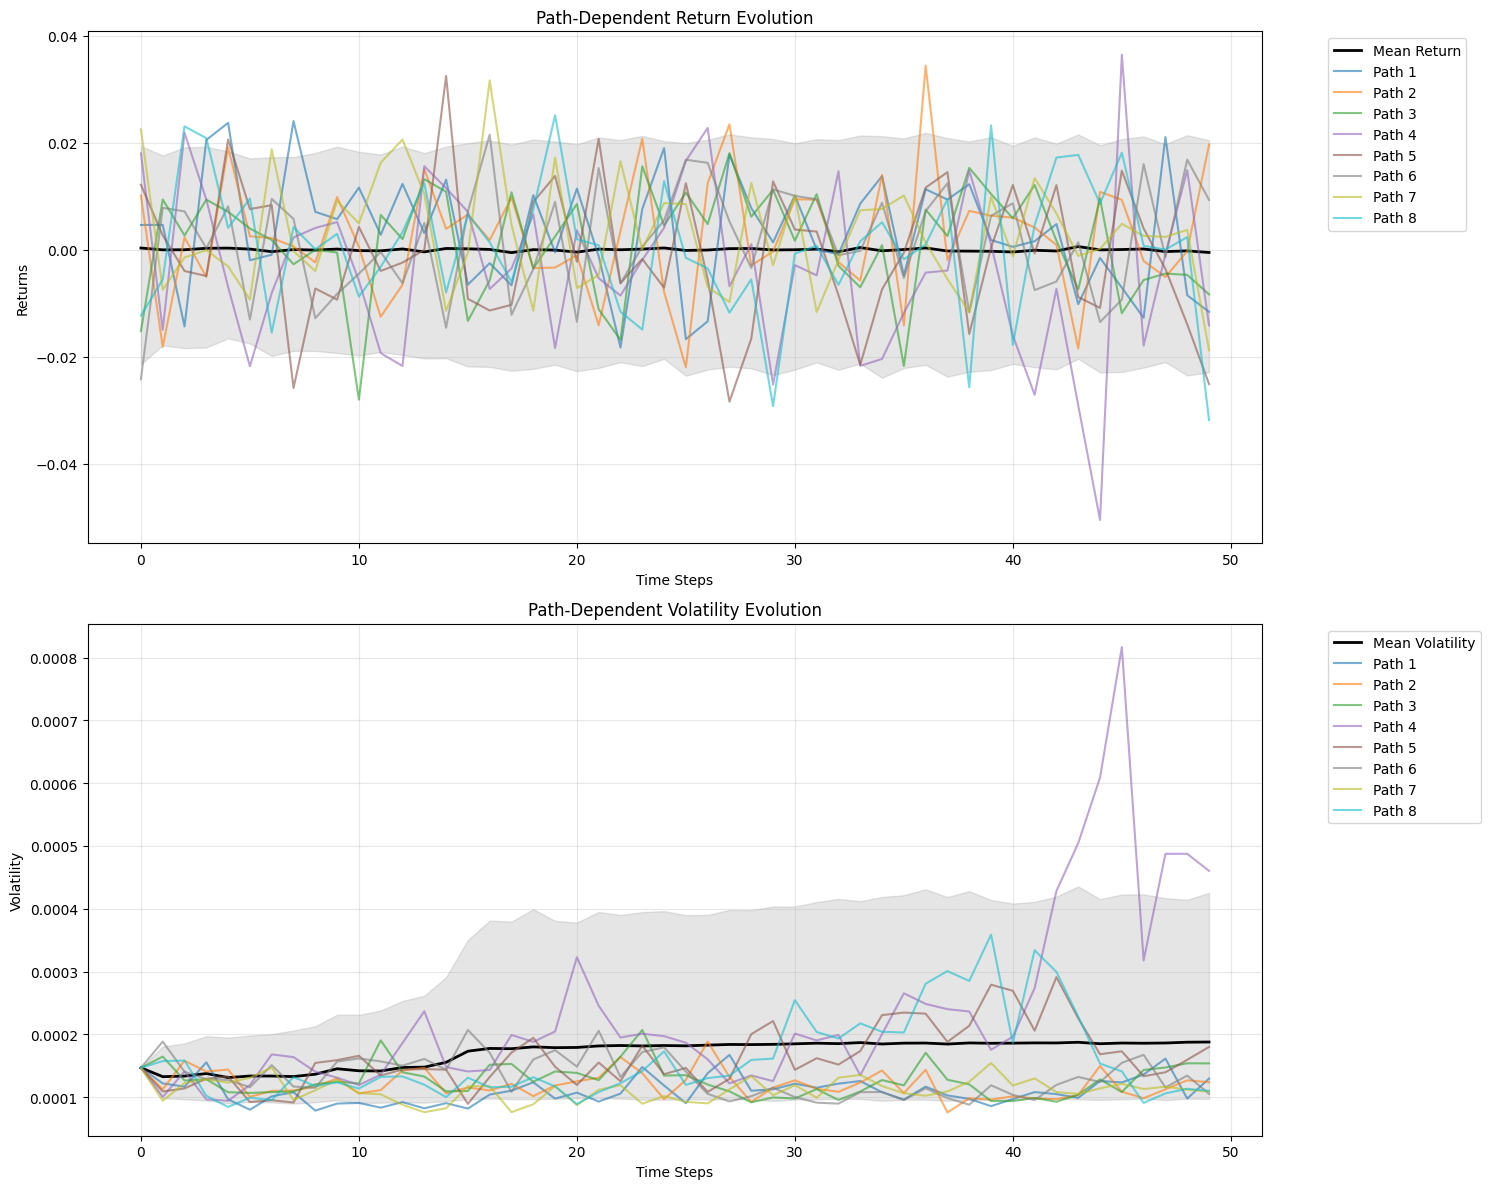

In [28]:
analyze_path_dependent_simulations(simulation_returns, simulation_params)


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import json


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import json

def save_simulation_results(simulation_returns, simulation_params, base_path='simulation_results'):
    """
    Save simulation results to files for later access
    """
    # Create timestamp for unique folder
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    save_dir = f"{base_path}_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)

    # Save returns
    np.save(f"{save_dir}/simulation_returns.npy", simulation_returns)

    # Save parameters
    for param_name, param_values in simulation_params.items():
        np.save(f"{save_dir}/{param_name.lower()}.npy", param_values)

    # Save metadata
    metadata = {
        'n_simulations': simulation_returns.shape[0],
        'n_steps': simulation_returns.shape[1],
        'parameters': list(simulation_params.keys()),
        'timestamp': timestamp
    }

    with open(f"{save_dir}/metadata.json", 'w') as f:
        json.dump(metadata, f)

    return save_dir

def load_simulation_results(directory):
    """
    Load previously saved simulation results
    """
    returns = np.load(f"{directory}/simulation_returns.npy")

    params = {}
    with open(f"{directory}/metadata.json", 'r') as f:
        metadata = json.load(f)

    for param_name in metadata['parameters']:
        params[param_name] = np.load(f"{directory}/{param_name.lower()}.npy")

    return returns, params, metadata

def analyze_path_dependent_simulations(simulation_returns, simulation_params):
    """
    Create comprehensive analysis plots of the simulation results
    """
    n_steps = simulation_returns.shape[1]

    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Path-Dependent Simulation Analysis', fontsize=16)

    # Plot 1: Returns distribution over time
    ax = axes[0, 0]
    sns.boxplot(data=pd.DataFrame(simulation_returns), ax=ax)
    ax.set_title('Returns Distribution Over Time')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Return')

    # Plot 2: Parameters evolution
    ax = axes[0, 1]
    for param_name, param_values in simulation_params.items():
        mean_values = np.mean(param_values, axis=0)
        std_values = np.std(param_values, axis=0)
        ax.plot(range(n_steps), mean_values, label=param_name)
        ax.fill_between(range(n_steps),
                       mean_values - std_values,
                       mean_values + std_values,
                       alpha=0.2)
    ax.set_title('Parameter Evolution')
    ax.set_xlabel('Time Step')
    ax.legend()

    # Plot 3: Cumulative returns distribution
    ax = axes[1, 0]
    cum_returns = np.cumsum(simulation_returns, axis=1)
    for percentile in [1, 5, 25, 50, 75, 95, 99]:
        values = np.percentile(cum_returns, percentile, axis=0)
        ax.plot(range(n_steps), values, label=f'{percentile}th percentile')
    ax.set_title('Cumulative Returns Distribution')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Cumulative Return')
    ax.legend()

    # Plot 4: Return correlation across time steps
    ax = axes[1, 1]
    corr_matrix = np.corrcoef(simulation_returns.T)
    sns.heatmap(corr_matrix, ax=ax)
    ax.set_title('Returns Correlation Across Time Steps')

    plt.tight_layout()
    return fig

def simulate_stock_prices(returns, initial_price=1.0):
    """
    Convert log returns into stock prices

    Args:
        returns: Array of shape (n_simulations, n_steps) containing log returns
        initial_price: Starting price for all simulations

    Returns:
        Array of shape (n_simulations, n_steps + 1) containing price paths
    """
    n_simulations, n_steps = returns.shape

    # Initialize prices array with an extra step for initial price
    prices = np.zeros((n_simulations, n_steps + 1))
    prices[:, 0] = initial_price

    # Convert log returns to prices
    # P_t = P_{t-1} * exp(r_t)
    cumulative_returns = np.cumsum(returns, axis=1)
    prices[:, 1:] = initial_price * np.exp(cumulative_returns)

    return prices

def plot_stock_prices(prices, path_indices=None, confidence_intervals=True, save_dir=None):
    """
    Plot simulated stock price paths

    Args:
        prices: Array of shape (n_simulations, n_steps) containing price paths
        path_indices: List of specific paths to highlight
        confidence_intervals: Whether to show confidence intervals
        save_dir: Directory to save the plot
    """
    fig, ax = plt.subplots(figsize=(15, 8))

    n_simulations, n_steps = prices.shape
    time_points = np.arange(n_steps)

    if confidence_intervals:
        # Calculate confidence intervals
        percentiles = [1, 5, 25, 50, 75, 95, 99]
        percentile_values = np.percentile(prices, percentiles, axis=0)

        # Plot confidence intervals
        ax.fill_between(time_points, percentile_values[0], percentile_values[-1],
                       alpha=0.1, color='blue', label='1st-99th percentile')
        ax.fill_between(time_points, percentile_values[1], percentile_values[-2],
                       alpha=0.2, color='blue', label='5th-95th percentile')
        ax.fill_between(time_points, percentile_values[2], percentile_values[-3],
                       alpha=0.3, color='blue', label='25th-75th percentile')

        # Plot median
        ax.plot(time_points, percentile_values[3], 'b-',
                label='Median', linewidth=2)

    # Plot specific paths if requested
    if path_indices is not None:
        for idx in path_indices:
            ax.plot(time_points, prices[idx], alpha=0.8,
                    label=f'Path {idx}')

    ax.set_title('Simulated Stock Price Paths')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Stock Price')
    ax.grid(True)
    ax.legend()

    if save_dir:
        plt.savefig(f"{save_dir}/stock_prices.png")

    return fig

def plot_price_distribution(prices, time_points=None, save_dir=None):
    """
    Plot the distribution of stock prices at different time points

    Args:
        prices: Array of shape (n_simulations, n_steps) containing price paths
        time_points: List of time points to analyze
        save_dir: Directory to save the plot
    """
    if time_points is None:
        time_points = [prices.shape[1]//4, prices.shape[1]//2, prices.shape[1]-1]

    fig, axes = plt.subplots(len(time_points), 1, figsize=(15, 5*len(time_points)))
    if len(time_points) == 1:
        axes = [axes]

    for i, t in enumerate(time_points):
        sns.histplot(prices[:, t], kde=True, ax=axes[i])
        axes[i].set_title(f'Price Distribution at t={t}')
        axes[i].set_xlabel('Stock Price')
        axes[i].set_ylabel('Count')

    plt.tight_layout()

    if save_dir:
        plt.savefig(f"{save_dir}/price_distributions.png")

    return fig

def plot_specific_paths(simulation_returns, simulation_params, path_indices, save_dir=None):
    """
    Plot specific simulation paths with their corresponding parameters
    """
    n_paths = len(path_indices)
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Plot returns
    ax = axes[0]
    for idx in path_indices:
        ax.plot(simulation_returns[idx], label=f'Path {idx}')
    ax.set_title('Specific Return Paths')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Return')
    ax.legend()

    # Plot parameters
    ax = axes[1]
    for param_name, param_values in simulation_params.items():
        for idx in path_indices:
            ax.plot(param_values[idx], label=f'{param_name} Path {idx}')
    ax.set_title('Parameter Values for Specific Paths')
    ax.set_xlabel('Time Step')
    ax.legend()

    plt.tight_layout()

    if save_dir:
        plt.savefig(f"{save_dir}/specific_paths.png")

    return fig

# Example usage:
"""
# After running simulations:
simulation_returns, simulation_params = simulate_path_dependent_returns(trained_model, final_dm)

# Save results
save_dir = save_simulation_results(simulation_returns, simulation_params)

# Create and save analysis plots
fig1 = analyze_path_dependent_simulations(simulation_returns, simulation_params)
fig1.savefig(f"{save_dir}/analysis_plots.png")

# Plot specific paths
fig2 = plot_specific_paths(simulation_returns, simulation_params, [0, 1, 2, 3, 4, 5, 6, 7, 8], save_dir)

# Later, to load results:
loaded_returns, loaded_params, metadata = load_simulation_results(save_dir)
"""

'\n# After running simulations:\nsimulation_returns, simulation_params = simulate_path_dependent_returns(trained_model, final_dm)\n\n# Save results\nsave_dir = save_simulation_results(simulation_returns, simulation_params)\n\n# Create and save analysis plots\nfig1 = analyze_path_dependent_simulations(simulation_returns, simulation_params)\nfig1.savefig(f"{save_dir}/analysis_plots.png")\n\n# Plot specific paths\nfig2 = plot_specific_paths(simulation_returns, simulation_params, [0, 1, 2, 3, 4, 5, 6, 7, 8], save_dir)\n\n# Later, to load results:\nloaded_returns, loaded_params, metadata = load_simulation_results(save_dir)\n'

In [39]:
# First, save the simulation results
save_dir = save_simulation_results(simulation_returns, simulation_params)
print(f"Results saved to: {save_dir}")

# Then load them
loaded_returns, loaded_params, metadata = load_simulation_results(save_dir)

Results saved to: simulation_results_20250119_170925


In [ ]:
import os
# List all directories that start with 'simulation_results'
saved_dirs = [d for d in os.listdir() if d.startswith('simulation_results')]
print("Available simulation results directories:", saved_dirs)

# Choose the directory you want to load (usually the most recent one)
if saved_dirs:
    save_dir = saved_dirs[-1]  # Get the last (most recent) directory
    loaded_returns, loaded_params, metadata = load_simulation_results(save_dir)
else:
    print("No saved simulation results found")

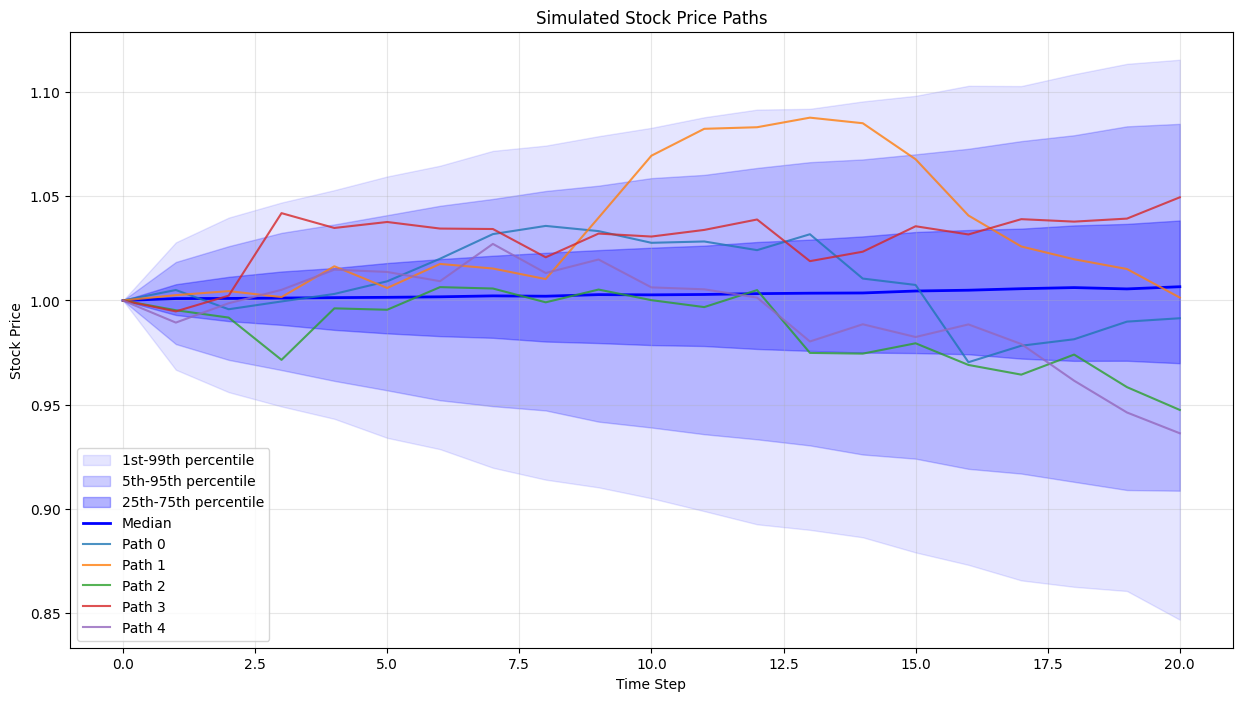

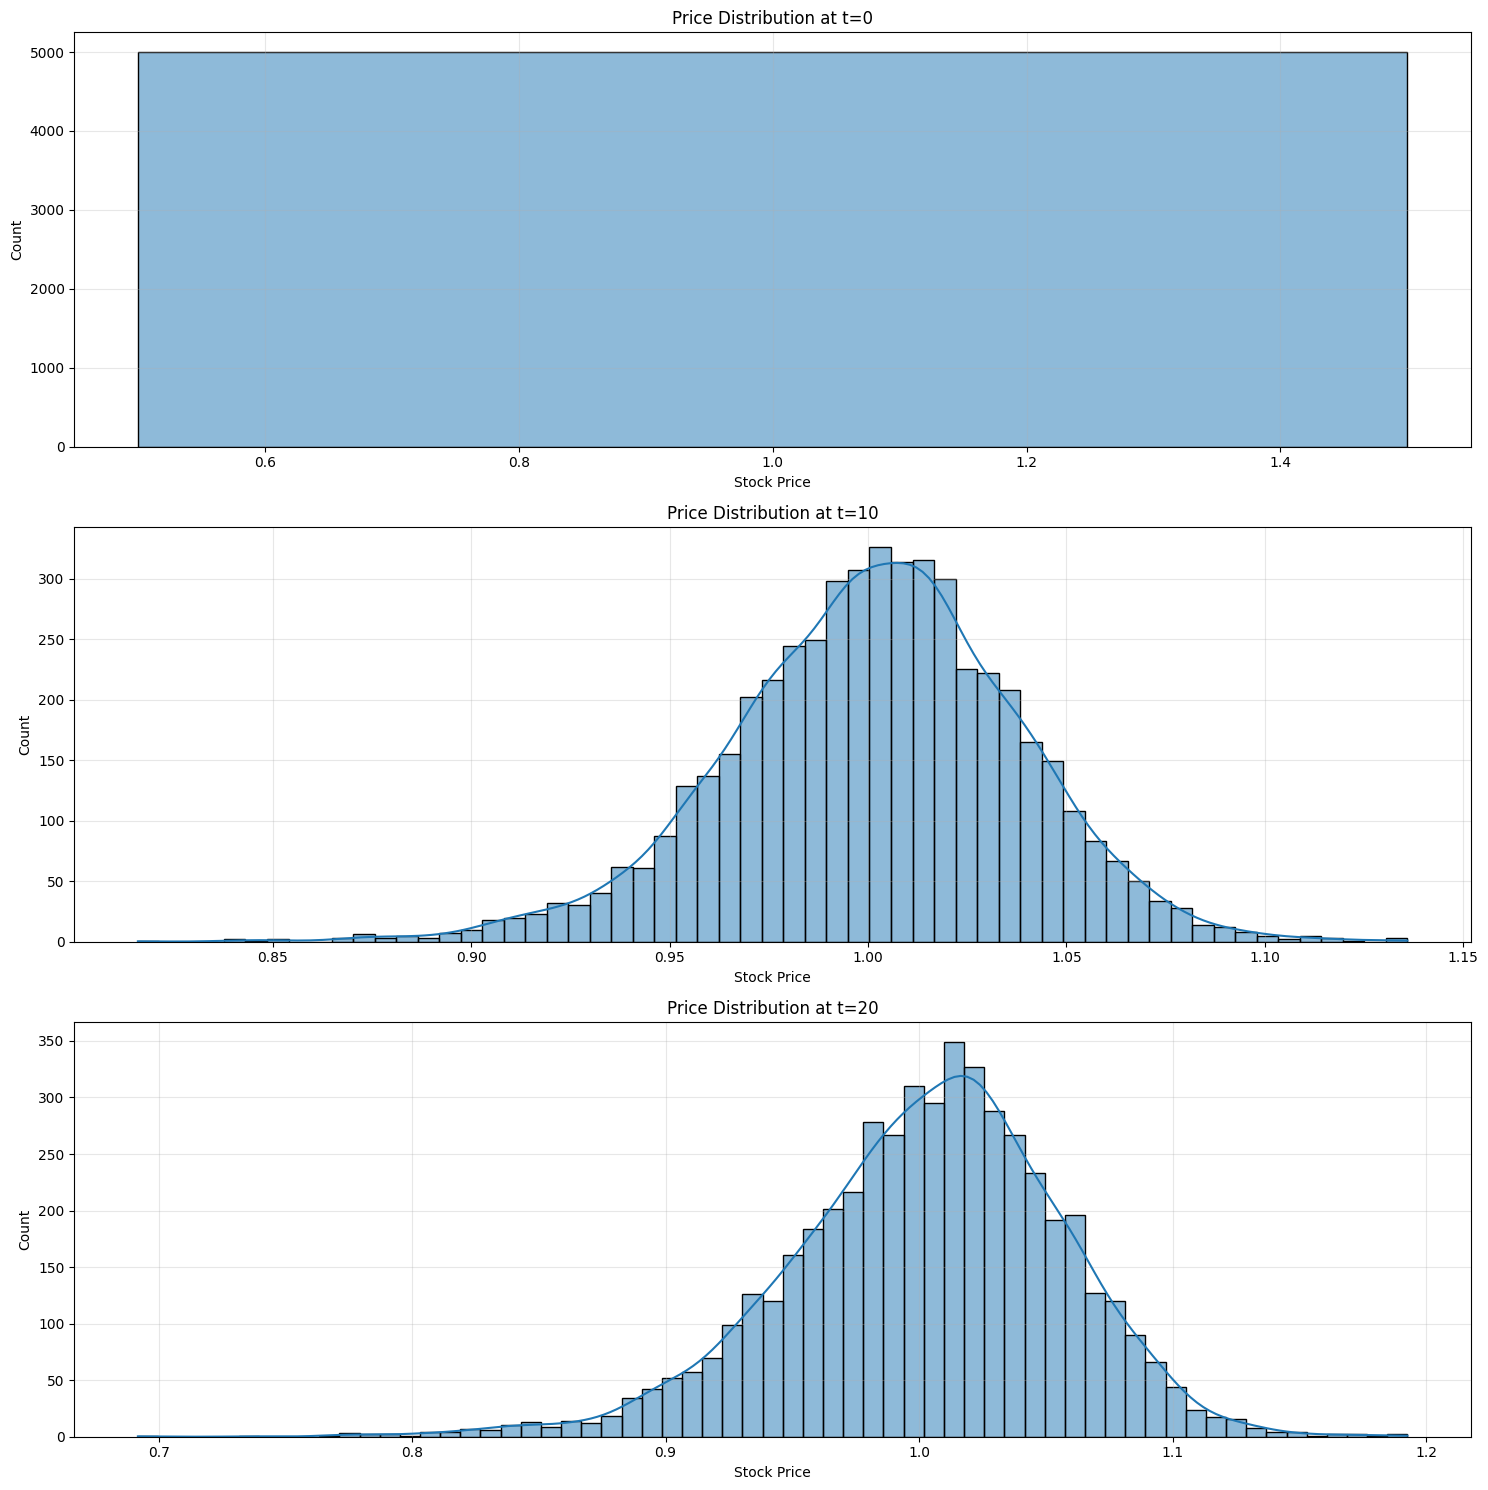

In [44]:
# Convert returns to prices
stock_prices = simulate_stock_prices(simulation_returns, initial_price=1.0)

# Plot price paths with confidence intervals and some specific paths
fig1 = plot_stock_prices(stock_prices,
                        path_indices=[0, 1, 2, 3, 4],  # Show first 5 paths
                        confidence_intervals=True,
                        save_dir=save_dir)

# Plot price distributions at different time points
fig2 = plot_price_distribution(stock_prices,
                             time_points=[0, 10, 20],  # Beginning, middle, end
                             save_dir=save_dir)

# Save the price data if needed
np.save(f"{save_dir}/stock_prices.npy", stock_prices)

In [54]:
import torch
import torch.nn as nn

class SineActivation(nn.Module):
    def forward(self, input):
        return torch.sin(input)


In [119]:
import torch
import torch.nn as nn
import pfhedge
from pfhedge.instruments import EuropeanOption, BrownianStock
from pfhedge.nn import MultiLayerPerceptron, BlackScholes
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

class SineActivation(nn.Module):
    def forward(self, x):
        return torch.sin(x)

class DeepHedgingModel:
    def __init__(
        self,
        strike_price,
        maturity,
        n_steps,
        interest_rate=0.0,
        is_call=True,
        hidden_size=32,
        n_layers=2,
    ):
        self.strike = strike_price
        self.maturity = maturity
        self.n_steps = n_steps
        self.interest_rate = interest_rate
        self.is_call = is_call

        # Initialize the hedger network
        self.hedger = MultiLayerPerceptron(
            in_features=3,  # price, time, moneyness
            n_units=hidden_size,
            out_features=1,
            n_layers=n_layers,
            activation=SineActivation(),  # Use the custom Sine activation
        )

        # Initialize the underlying stock
        self.stock = BrownianStock(dt=maturity/n_steps)

        # Simulate the stock to initialize the 'spot' buffer
        self.stock.simulate(n_paths=1, time_horizon=maturity)

        # Initialize the option
        self.option = EuropeanOption(
            underlier=self.stock,
            strike=strike_price,
            maturity=maturity,
            call=is_call,
        )

        # Initialize Black-Scholes model for comparison
        self.bs_hedger = BlackScholes(self.option)

    def prepare_price_paths(self, price_paths):
        """Convert price paths to the format expected by pfhedge"""
        # Convert to torch tensor if necessary
        if not isinstance(price_paths, torch.Tensor):
            price_paths = torch.tensor(price_paths, dtype=torch.float32)

        # Calculate log returns
        log_returns = torch.log(price_paths[:, 1:] / price_paths[:, :-1])

        return log_returns

    def get_hedge_inputs(self, stock_prices, times):
        """Prepare inputs for the neural network"""
        batch_size = stock_prices.size(0)
        n_steps = stock_prices.size(1)

        # Expand dimensions to match
        times = times.view(1, -1).repeat(batch_size, 1)

        # Calculate moneyness
        moneyness = stock_prices / self.strike

        # Stack inputs
        inputs = torch.stack([
            stock_prices,
            times,
            moneyness
        ], dim=-1)

        return inputs
    def train(
        self,
        price_paths,
        n_epochs=100,
        batch_size=256,
        learning_rate=1e-3,
        device="cuda" if torch.cuda.is_available() else "cpu"
    ):
        print(f"Training on device: {device}")

        # Prepare data
        log_returns = self.prepare_price_paths(price_paths).to(device)
        dataset = TensorDataset(log_returns)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        # Move models to device
        self.hedger = self.hedger.to(device)
        self.stock = self.stock.to(device)
        self.option = self.option.to(device)

        # Time grid
        times = torch.linspace(0, self.maturity, self.n_steps + 1, device=device)

        # Initialize optimizer
        optimizer = torch.optim.Adam(self.hedger.parameters(), lr=learning_rate)

        # Training loop
        for epoch in range(n_epochs):
            total_loss = 0.0
            num_batches = 0
            for batch_idx, (batch_returns,) in enumerate(dataloader):
                # Reset gradients
                optimizer.zero_grad()

                # Set the stock increments and initial price
                self.stock.register_buffer('increments', batch_returns)
                self.stock.register_buffer('init_price', torch.ones(batch_returns.size(0), device=device))

                # Simulate stock prices
                stock_prices = torch.exp(torch.cumsum(torch.cat([
                    torch.zeros(batch_returns.size(0), 1, device=device),
                    batch_returns
                ], dim=1), dim=1))

                # Print debug info for first batch of first epoch
                if epoch == 0 and batch_idx == 0:
                    print(f"\nInitial debug info:")
                    print(f"Stock prices shape: {stock_prices.shape}")
                    print(f"Stock prices range: [{stock_prices.min():.4f}, {stock_prices.max():.4f}]")

                # Get hedge ratios
                inputs = self.get_hedge_inputs(stock_prices, times)
                hedge_ratios = self.hedger(inputs.view(-1, 3)).view(batch_returns.size(0), -1)

                if epoch == 0 and batch_idx == 0:
                    print(f"Hedge ratios shape: {hedge_ratios.shape}")
                    print(f"Hedge ratios range: [{hedge_ratios.min():.4f}, {hedge_ratios.max():.4f}]")

                # Get option payoff
                payoff = self.option.payoff()
                price = payoff.mean()
                pnl = payoff - price

                if epoch == 0 and batch_idx == 0:
                    print(f"Payoff range: [{payoff.min():.4f}, {payoff.max():.4f}]")
                    print(f"PnL range: [{pnl.min():.4f}, {pnl.max():.4f}]")

                # Calculate trading gains
                trading_gains = (hedge_ratios[:, :-1] * batch_returns).sum(dim=1)
                hedged_pnl = pnl - trading_gains

                # Modified loss function with regularization
                variance_loss = hedged_pnl.var()
                mean_loss = torch.abs(hedged_pnl.mean())
                hedge_smoothness = torch.diff(hedge_ratios, dim=1).pow(2).mean()

                loss = variance_loss + 0.1 * mean_loss + 0.01 * hedge_smoothness

                if epoch == 0 and batch_idx == 0:
                    print(f"\nLoss components:")
                    print(f"Variance loss: {variance_loss.item():.6f}")
                    print(f"Mean loss: {mean_loss.item():.6f}")
                    print(f"Hedge smoothness: {hedge_smoothness.item():.6f}")
                    print(f"Total loss: {loss.item():.6f}")

                # Backward pass if loss is valid
                if torch.isfinite(loss) and loss > 0:
                    loss.backward()
                    optimizer.step()

                    total_loss += loss.item()
                    num_batches += 1
                else:
                    print(f"Warning: Invalid loss value: {loss.item()}")

        # Print progress
        if (epoch + 1) % 10 == 0 and num_batches > 0:
            avg_loss = total_loss / num_batches
            print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.6f}")


def plot_hedging_results(model, price_paths, save_dir=None):
    # Evaluate model
    metrics, pnl_deep, pnl_bs = model.evaluate(price_paths)

    # Plot PnL distributions
    plt.figure(figsize=(12, 6))
    plt.hist(pnl_deep, bins=50, alpha=0.5, label='Deep Hedging')
    plt.hist(pnl_bs, bins=50, alpha=0.5, label='Black-Scholes')
    plt.xlabel('PnL')
    plt.ylabel('Frequency')
    plt.title('PnL Distribution: Deep Hedging vs Black-Scholes')
    plt.legend()

    if save_dir:
        plt.savefig(f"{save_dir}/hedging_pnl_distribution.png")

    plt.show()

    # Print metrics
    print("\nHedging Performance Metrics:")
    print(f"Deep Hedging - Mean PnL: {metrics['deep_hedging_pnl_mean']:.6f}, Std: {metrics['deep_hedging_pnl_std']:.6f}")
    print(f"Black-Scholes - Mean PnL: {metrics['bs_pnl_mean']:.6f}, Std: {metrics['bs_pnl_std']:.6f}")

In [156]:
def evaluate(self, price_paths, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Evaluate hedging performance comparing deep hedging strategy with Black-Scholes.

    Args:
        price_paths: Tensor of stock price paths
        device: Computing device to use

    Returns:
        tuple: (metrics dictionary, deep hedging PnL, Black-Scholes PnL)
    """
    with torch.no_grad():
        # Move models to device if needed
        self.hedger = self.hedger.to(device)
        self.stock = self.stock.to(device)
        self.option = self.option.to(device)

        # Prepare data
        log_returns = self.prepare_price_paths(price_paths).to(device)

        # Set the stock increments and initial price
        self.stock.register_buffer('increments', log_returns)
        self.stock.register_buffer('init_price', torch.ones(log_returns.size(0), device=device))

        # Time grid
        times = torch.linspace(0, self.maturity, self.n_steps + 1, device=device)

        # Simulate stock prices
        stock_prices = torch.exp(torch.cumsum(torch.cat([
            torch.zeros(log_returns.size(0), 1, device=device),
            log_returns
        ], dim=1), dim=1))

        # Get hedge ratios from our model
        inputs = self.get_hedge_inputs(stock_prices, times)
        hedge_ratios = self.hedger(inputs.view(-1, 3)).view(log_returns.size(0), -1)

        # Get option payoff
        payoff = self.option.payoff()
        price = payoff.mean()
        pnl = payoff - price

        # Calculate trading gains for deep hedging
        trading_gains_deep = (hedge_ratios[:, :-1] * log_returns).sum(dim=1)
        hedged_pnl_deep = pnl - trading_gains_deep

        # Get Black-Scholes hedge ratios using the initialized bs_hedger
        bs_ratios = self.bs_hedger(times, stock_prices)

        # Calculate trading gains for Black-Scholes
        trading_gains_bs = (bs_ratios[:, :-1] * log_returns).sum(dim=1)
        hedged_pnl_bs = pnl - trading_gains_bs

        # Calculate metrics
        metrics = {
            'deep_hedging_pnl_mean': hedged_pnl_deep.mean().item(),
            'deep_hedging_pnl_std': hedged_pnl_deep.std().item(),
            'bs_pnl_mean': hedged_pnl_bs.mean().item(),
            'bs_pnl_std': hedged_pnl_bs.std().item(),
        }

        return metrics, hedged_pnl_deep.cpu().numpy(), hedged_pnl_bs.cpu().numpy()

In [217]:
class DeepHedgingModel(nn.Module):
    def __init__(
        self,
        strike_price,
        maturity,
        n_steps,
        interest_rate=0.0,
        is_call=True,
        hidden_size=32,
        n_layers=2,
    ):
        super(DeepHedgingModel, self).__init__()
        self.strike = strike_price
        self.maturity = maturity
        self.n_steps = n_steps
        self.interest_rate = interest_rate
        self.is_call = is_call

        # Initialize the hedger network
        self.hedger = MultiLayerPerceptron(
            in_features=3,  # price, time, moneyness
            n_units=hidden_size,
            out_features=1,
            n_layers=n_layers,
            activation=SineActivation(),
        )

        # Initialize the underlying stock with volatility
        self.stock = BrownianStock(
            dt=maturity/n_steps,
            sigma=0.2  # Set volatility for BS comparison
        )

        # Initialize with a single path simulation
        self.stock.simulate(n_paths=1, time_horizon=maturity)

        # Initialize the option
        self.option = EuropeanOption(
            underlier=self.stock,
            strike=strike_price,
            maturity=maturity,
            call=is_call,
        )

        # Initialize Black-Scholes hedger with the option
        self.bs_hedger = BlackScholes(
            derivative=self.option
        )

    def forward(self, x):
        return self.hedger(x)

    def train(
        self,
        price_paths,
        n_epochs=300,
        batch_size=256,
        learning_rate=1e-3,
        device="cuda" if torch.cuda.is_available() else "cpu"
    ):
        print(f"Training on device: {device}")

        # Prepare data
        log_returns = self.prepare_price_paths(price_paths).to(device)
        dataset = TensorDataset(log_returns)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        # Move models to device
        self.hedger = self.hedger.to(device)
        self.stock = self.stock.to(device)
        self.option = self.option.to(device)

        # Time grid
        times = torch.linspace(0, self.maturity, self.n_steps + 1, device=device)

        # Initialize optimizer
        optimizer = torch.optim.Adam(self.hedger.parameters(), lr=learning_rate)

        # Training loop
        for epoch in range(n_epochs):
            total_loss = 0.0
            num_batches = 0

            for batch_idx, (batch_returns,) in enumerate(dataloader):
                # Reset gradients
                optimizer.zero_grad()

                # Set the stock increments and initial price
                self.stock.register_buffer('increments', batch_returns)
                self.stock.register_buffer('init_price', torch.ones(batch_returns.size(0), device=device))

                # Simulate stock prices
                stock_prices = torch.exp(torch.cumsum(torch.cat([
                    torch.zeros(batch_returns.size(0), 1, device=device),
                    batch_returns
                ], dim=1), dim=1))

                # Print debug info for first batch of first epoch
                if epoch == 0 and batch_idx == 0:
                    print(f"\nInitial debug info:")
                    print(f"Stock prices shape: {stock_prices.shape}")
                    print(f"Stock prices range: [{stock_prices.min():.4f}, {stock_prices.max():.4f}]")

                # Get hedge ratios
                inputs = self.get_hedge_inputs(stock_prices, times)
                hedge_ratios = self.hedger(inputs.view(-1, 3)).view(batch_returns.size(0), -1)

                if epoch == 0 and batch_idx == 0:
                    print(f"Hedge ratios shape: {hedge_ratios.shape}")
                    print(f"Hedge ratios range: [{hedge_ratios.min():.4f}, {hedge_ratios.max():.4f}]")

                # Get option payoff
                payoff = self.option.payoff()
                price = payoff.mean()
                pnl = payoff - price

                if epoch == 0 and batch_idx == 0:
                    print(f"Payoff range: [{payoff.min():.4f}, {payoff.max():.4f}]")
                    print(f"PnL range: [{pnl.min():.4f}, {pnl.max():.4f}]")

                # Calculate trading gains
                trading_gains = (hedge_ratios[:, :-1] * batch_returns).sum(dim=1)
                hedged_pnl = pnl - trading_gains

                # Modified loss function with regularization
                variance_loss = hedged_pnl.var()
                mean_loss = torch.abs(hedged_pnl.mean())
                hedge_smoothness = torch.diff(hedge_ratios, dim=1).pow(2).mean()

                loss = variance_loss + 0.1 * mean_loss + 0.01 * hedge_smoothness

                if epoch == 0 and batch_idx == 0:
                    print(f"\nLoss components:")
                    print(f"Variance loss: {variance_loss.item():.6f}")
                    print(f"Mean loss: {mean_loss.item():.6f}")
                    print(f"Hedge smoothness: {hedge_smoothness.item():.6f}")
                    print(f"Total loss: {loss.item():.6f}")

                # Backward pass if loss is valid
                if torch.isfinite(loss) and loss > 0:
                    loss.backward()
                    optimizer.step()

                    total_loss += loss.item()
                    num_batches += 1
                else:
                    print(f"Warning: Invalid loss value: {loss.item()}")

            # Print progress
            if (epoch + 1) % 10 == 0 and num_batches > 0:
                avg_loss = total_loss / num_batches
                print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.6f}")

    def prepare_price_paths(self, price_paths):
        """Convert price paths to the format expected by pfhedge"""
        if not isinstance(price_paths, torch.Tensor):
            price_paths = torch.tensor(price_paths, dtype=torch.float32)
        log_returns = torch.log(price_paths[:, 1:] / price_paths[:, :-1])
        return log_returns

    def get_hedge_inputs(self, stock_prices, times):
        """Prepare inputs for the neural network"""
        batch_size = stock_prices.size(0)
        n_steps = stock_prices.size(1)

        # Expand dimensions to match
        times = times.view(1, -1).repeat(batch_size, 1)

        # Calculate moneyness
        moneyness = stock_prices / self.strike

        # Stack inputs
        inputs = torch.stack([
            stock_prices,
            times,
            moneyness
        ], dim=-1)

        return inputs
    def evaluate(self, price_paths, device="cuda" if torch.cuda.is_available() else "cpu"):
        """
        Evaluate hedging performance comparing deep hedging strategy with Black-Scholes.
        """
        if not isinstance(price_paths, torch.Tensor):
            raise ValueError("price_paths must be a tensor.")
        with torch.no_grad():
            # Move models to device if needed
            self.hedger = self.hedger.to(device)
            self.stock = self.stock.to(device)
            self.option = self.option.to(device)
            self.bs_hedger = self.bs_hedger.to(device)

            # Prepare data
            log_returns = self.prepare_price_paths(price_paths).to(device)

            # Set the stock increments and initial price
            self.stock.register_buffer('increments', log_returns)
            self.stock.register_buffer('init_price', torch.ones(log_returns.size(0), device=device))

            # Time grid
            times = torch.linspace(0, self.maturity, self.n_steps + 1, device=device)

            # Simulate stock prices
            stock_prices = torch.exp(torch.cumsum(torch.cat([
                torch.zeros(log_returns.size(0), 1, device=device),
                log_returns
            ], dim=1), dim=1))

            # Get hedge ratios from our model
            inputs = self.get_hedge_inputs(stock_prices, times)
            hedge_ratios = self.hedger(inputs.view(-1, 3)).view(log_returns.size(0), -1)

            # Get option payoff
            payoff = self.option.payoff()
            price = payoff.mean()
            pnl = payoff - price

            # Calculate trading gains for deep hedging
            trading_gains_deep = (hedge_ratios[:, :-1] * log_returns).sum(dim=1)
            hedged_pnl_deep = pnl - trading_gains_deep

            # Get Black-Scholes hedge ratios for each time step
            bs_ratios = []
            for t in range(stock_prices.size(1)):
                # Update stock spot price for current time step
                self.stock.register_buffer('spot', stock_prices[:, t:t+1])
                # Get BS delta for this time step
                delta = self.bs_hedger(self.option)
                bs_ratios.append(delta)

            # Combine all ratios
            bs_ratios = torch.stack(bs_ratios, dim=1)

            # Calculate trading gains for Black-Scholes
            trading_gains_bs = (bs_ratios[:, :-1] * log_returns).sum(dim=1)
            hedged_pnl_bs = pnl - trading_gains_bs

            # Calculate metrics
            metrics = {
                'deep_hedging_pnl_mean': hedged_pnl_deep.mean().item(),
                'deep_hedging_pnl_std': hedged_pnl_deep.std().item(),
                'bs_pnl_mean': hedged_pnl_bs.mean().item(),
                'bs_pnl_std': hedged_pnl_bs.std().item(),
            }

            return metrics, hedged_pnl_deep.cpu().numpy(), hedged_pnl_bs.cpu().numpy()

In [216]:
def plot_hedging_results(model, price_paths, save_dir=None):
    """
    Plot and analyze hedging results comparing deep hedging vs Black-Scholes.

    Args:
        model: Trained DeepHedgingModel instance
        price_paths: Price paths tensor used for evaluation
        save_dir: Optional directory to save plots
    """
    # Evaluate model
    metrics, pnl_deep, pnl_bs = model.evaluate(price_paths)

    # Create figure
    plt.figure(figsize=(12, 6))

    # Plot PnL distributions
    plt.hist(pnl_deep, bins=50, alpha=0.5, label='Deep Hedging', color='blue')
    plt.hist(pnl_bs, bins=50, alpha=0.5, label='Black-Scholes', color='red')

    # Add vertical lines for means
    plt.axvline(metrics['deep_hedging_pnl_mean'], color='blue', linestyle='--', alpha=0.8)
    plt.axvline(metrics['bs_pnl_mean'], color='red', linestyle='--', alpha=0.8)

    # Customize plot
    plt.xlabel('PnL')
    plt.ylabel('Frequency')
    plt.title('PnL Distribution: Deep Hedging vs Black-Scholes')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Save if directory provided
    if save_dir:
        plt.savefig(f"{save_dir}/hedging_pnl_distribution.png", dpi=300, bbox_inches='tight')

    plt.show()

    # Print metrics
    print("\nHedging Performance Metrics:")
    print("-" * 50)
    print(f"Deep Hedging:")
    print(f"  Mean PnL: {metrics['deep_hedging_pnl_mean']:.6f}")
    print(f"  PnL Std: {metrics['deep_hedging_pnl_std']:.6f}")
    print(f"  Sharpe Ratio: {metrics['deep_hedging_pnl_mean'] / (metrics['deep_hedging_pnl_std'] + 1e-8):.4f}")
    print("\nBlack-Scholes:")
    print(f"  Mean PnL: {metrics['bs_pnl_mean']:.6f}")
    print(f"  PnL Std: {metrics['bs_pnl_std']:.6f}")
    print(f"  Sharpe Ratio: {metrics['bs_pnl_mean'] / (metrics['bs_pnl_std'] + 1e-8):.4f}")

In [220]:
# Initialize the model
model = DeepHedgingModel(
    strike_price=1.0,  # ATM option since initial price is 1.0
    maturity=20,       # 20 trading days
    n_steps=20,        # 20 hedging steps matching your simulation
    interest_rate=0.0, # Zero interest rate for simplicity
    is_call=True       # Call option
)
# Ensure stock_prices is a tensor and move it to the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
stock_prices = stock_prices.to(device)
# Train the model
model.train(
    price_paths=stock_prices,
    n_epochs=300,
    batch_size=256,
    learning_rate=1e-3
# )
# # Evaluate and plot results
# metrics, pnl_deep, pnl_bs = model.evaluate(stock_prices)
plot_hedging_results(model, stock_prices, save_dir="results/")

AttributeError: EuropeanOption has no attribute size

In [221]:
def plot_hedging_results(model, stock_prices, save_dir="results/"):
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)

    # Evaluate model
    metrics, pnl_deep, pnl_bs = model.evaluate(stock_prices)

    # Plot PnL distributions
    plt.figure(figsize=(12, 6))
    plt.hist(pnl_deep, bins=50, alpha=0.5, label='Deep Hedging', density=True)
    plt.hist(pnl_bs, bins=50, alpha=0.5, label='Black-Scholes', density=True)
    plt.xlabel('PnL')
    plt.ylabel('Density')
    plt.title('PnL Distribution Comparison')
    plt.legend()
    plt.savefig(os.path.join(save_dir, 'pnl_distribution.png'))
    plt.close()

    # Print metrics
    print("\nHedging Performance Metrics:")
    print(f"Deep Hedging - Mean PnL: {metrics['deep_hedging_pnl_mean']:.6f}")
    print(f"Deep Hedging - Std PnL: {metrics['deep_hedging_pnl_std']:.6f}")
    print(f"Black-Scholes - Mean PnL: {metrics['bs_pnl_mean']:.6f}")
    print(f"Black-Scholes - Std PnL: {metrics['bs_pnl_std']:.6f}")

    return metrics

In [229]:
# Ensure stock_prices is a tensor and move it to the correct device
if not isinstance(stock_prices, torch.Tensor):
    stock_prices = torch.tensor(stock_prices, dtype=torch.float32)
# Move to the device of the model
device = next(model.parameters()).device
stock_prices = stock_prices.to(device)
print("Stock prices device:", stock_prices.device)
print("Stock prices dtype:", stock_prices.dtype)
stock_prices = stock_prices.type(torch.float32)
print("Stock prices device:", stock_prices.device)
print("Stock prices dtype:", stock_prices.dtype)
print("Stock prices shape:", stock_prices.shape)


Stock prices device: cuda:0
Stock prices dtype: torch.float32
Stock prices device: cuda:0
Stock prices dtype: torch.float32
Stock prices shape: torch.Size([5000, 21])


In [233]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class DailyHedgingModel(nn.Module):
    def __init__(
        self,
        strike_price,
        n_steps,
        hidden_size=64
    ):
        super(DailyHedgingModel, self).__init__()
        self.strike = strike_price
        self.n_steps = n_steps

        # Simplified hedging network for daily returns
        self.hedger = nn.Sequential(
            nn.Linear(2, hidden_size),  # Input: [price, moneyness]
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            nn.Tanh()  # Constrain hedge ratios between -1 and 1
        )

    def forward(self, x):
        return self.hedger(x)

    def calculate_payoff(self, final_prices):
        """Calculate call option payoff"""
        return torch.maximum(final_prices - self.strike, torch.zeros_like(final_prices))

    def get_hedge_ratios(self, prices, moneyness):
        """Calculate hedge ratios for given prices and moneyness"""
        batch_size = prices.size(0)
        n_steps = prices.size(1) - 1

        # Prepare inputs for each time step
        inputs = torch.stack([
            prices[:, :-1].reshape(-1),  # Flatten prices except last timestep
            moneyness[:, :-1].reshape(-1)  # Flatten moneyness except last timestep
        ], dim=1)

        # Get hedge ratios and reshape back
        hedge_ratios = self.hedger(inputs).reshape(batch_size, n_steps)
        return hedge_ratios

    def train_daily(
        self,
        price_paths,
        n_epochs=1000,
        batch_size=256,
        learning_rate=1e-3,
        device="cuda" if torch.cuda.is_available() else "cpu"
    ):
        self.to(device)
        print(f"Training on device: {device}")

        # Prepare data
        daily_returns = (price_paths[:, 1:] / price_paths[:, :-1]) - 1
        dataset = TensorDataset(daily_returns)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        # Initialize optimizer
        optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)

        for epoch in range(n_epochs):
            total_loss = 0
            num_batches = 0

            for batch_idx, (batch_returns,) in enumerate(dataloader):
                optimizer.zero_grad()

                # Reconstruct price paths for this batch
                batch_size = batch_returns.size(0)
                prices = torch.ones(batch_size, self.n_steps + 1, device=device)
                prices[:, 1:] = torch.cumprod(1 + batch_returns, dim=1)

                # Calculate moneyness
                moneyness = prices / self.strike

                # Get hedge ratios
                hedge_ratios = self.get_hedge_ratios(prices, moneyness)

                # Calculate trading PnL
                trading_pnl = (hedge_ratios * batch_returns).sum(dim=1)

                # Calculate option payoff
                option_payoff = self.calculate_payoff(prices[:, -1])
                option_price = option_payoff.mean()
                target_pnl = option_payoff - option_price

                # Calculate hedged PnL
                hedged_pnl = target_pnl - trading_pnl

                # Loss function: minimize variance and mean of hedged PnL
                loss = hedged_pnl.var() + 0.1 * torch.abs(hedged_pnl.mean())

                if torch.isfinite(loss) and loss > 0:
                    loss.backward()
                    optimizer.step()
                    total_loss += loss.item()
                    num_batches += 1

                # Print first batch statistics for debugging
                if epoch == 0 and batch_idx == 0:
                    print(f"\nInitial batch statistics:")
                    print(f"Price range: [{prices.min():.4f}, {prices.max():.4f}]")
                    print(f"Hedge ratios range: [{hedge_ratios.min():.4f}, {hedge_ratios.max():.4f}]")
                    print(f"Option payoff range: [{option_payoff.min():.4f}, {option_payoff.max():.4f}]")
                    print(f"Initial loss: {loss.item():.6f}")

            if (epoch + 1) % 100 == 0:
                avg_loss = total_loss / num_batches if num_batches > 0 else float('nan')
                print(f"Epoch [{epoch+1}/{n_epochs}], Avg Loss: {avg_loss:.6f}")

    def evaluate_daily(self, price_paths, device="cuda" if torch.cuda.is_available() else "cpu"):
        """Evaluate hedging performance on daily basis"""
        self.to(device)
        with torch.no_grad():
            # Calculate daily returns
            daily_returns = (price_paths[:, 1:] / price_paths[:, :-1]) - 1

            # Reconstruct prices
            prices = torch.ones_like(price_paths)
            prices[:, 1:] = torch.cumprod(1 + daily_returns, dim=1)

            # Calculate moneyness
            moneyness = prices / self.strike

            # Get hedge ratios
            hedge_ratios = self.get_hedge_ratios(prices, moneyness)

            # Calculate trading PnL
            trading_pnl = (hedge_ratios * daily_returns).sum(dim=1)

            # Calculate option payoff
            option_payoff = self.calculate_payoff(prices[:, -1])
            option_price = option_payoff.mean()
            target_pnl = option_payoff - option_price

            # Calculate hedged PnL
            hedged_pnl = target_pnl - trading_pnl

            metrics = {
                'mean_pnl': hedged_pnl.mean().item(),
                'std_pnl': hedged_pnl.std().item(),
                'min_pnl': hedged_pnl.min().item(),
                'max_pnl': hedged_pnl.max().item(),
                'hedge_ratio_mean': hedge_ratios.mean().item(),
                'hedge_ratio_std': hedge_ratios.std().item()
            }

            return metrics, hedge_ratios.cpu().numpy(), hedged_pnl.cpu().numpy()

In [238]:
import matplotlib.pyplot as plt
import numpy as np

def plot_daily_hedging_results(hedge_ratios, hedged_pnl, save_dir="results/"):
    import os
    os.makedirs(save_dir, exist_ok=True)

    # Plot hedge ratio distribution
    plt.figure(figsize=(10, 6))
    plt.hist(hedge_ratios.flatten(), bins=50,)
    plt.title('Distribution of Hedge Ratios')
    plt.xlabel('Hedge Ratio')
    plt.ylabel('Density')
    plt.savefig(os.path.join(save_dir, 'hedge_ratios.png'))
    plt.show()  # Add this line
    plt.close()

    # Plot PnL distribution
    plt.figure(figsize=(10, 6))
    plt.hist(hedged_pnl, bins=50)
    plt.title('Distribution of Hedged PnL')
    plt.xlabel('PnL')
    plt.ylabel('Density')
    plt.savefig(os.path.join(save_dir, 'hedged_pnl.png'))
    plt.show()  # Add this line
    plt.close()

    # Plot sample paths of hedge ratios
    plt.figure(figsize=(12, 6))
    for i in range(min(5, hedge_ratios.shape[0])):
        plt.plot(hedge_ratios[i], alpha=0.7, label=f'Path {i+1}')
    plt.title('Sample Hedge Ratio Paths')
    plt.xlabel('Time Step')
    plt.ylabel('Hedge Ratio')
    plt.legend()
    plt.savefig(os.path.join(save_dir, 'hedge_paths.png'))
    plt.show()  # Add this line
    plt.close()


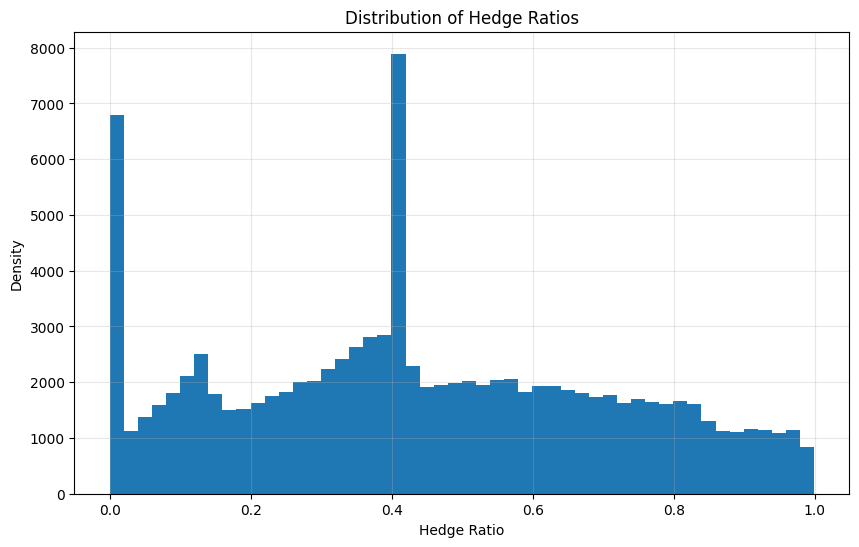

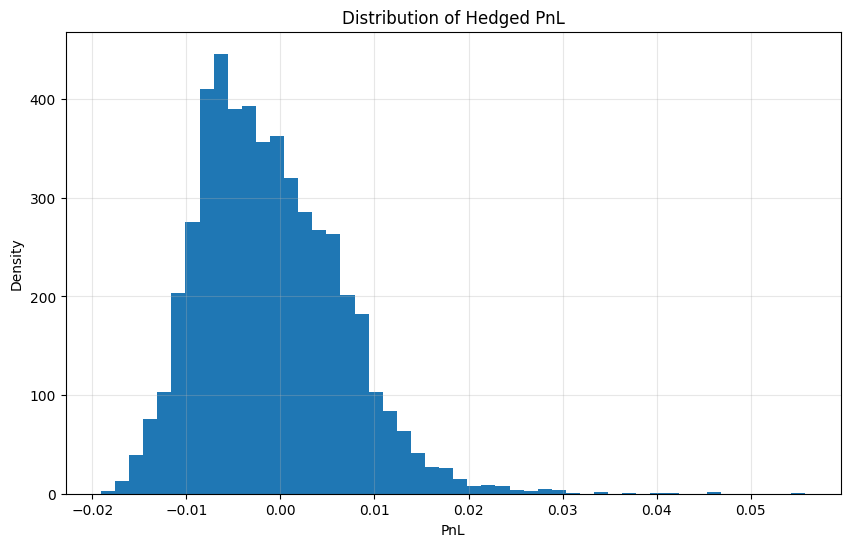

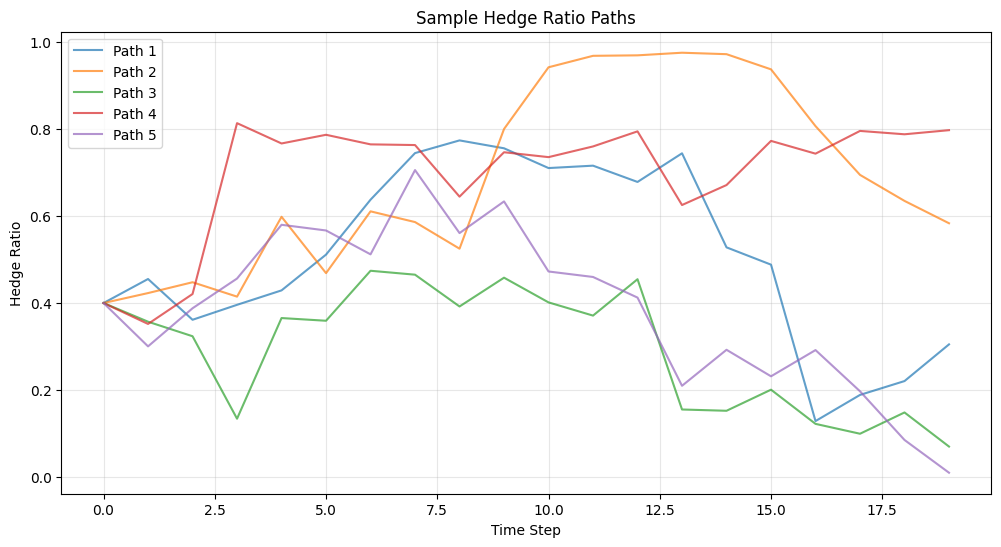

In [239]:
# Initialize the daily hedging model
model = DailyHedgingModel(
    strike_price=1.0,  # ATM option
    n_steps=20,        # 20 daily steps
)

# Train the model
model.train_daily(
    price_paths=stock_prices,
    n_epochs=1000,
    batch_size=256,
    learning_rate=1e-3
)

# Evaluate the model
metrics, hedge_ratios, hedged_pnl = model.evaluate_daily(stock_prices)

# Print metrics
print("\nHedging Performance Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.6f}")

Plot results
plot_daily_hedging_results(hedge_ratios, hedged_pnl, save_dir="results/")